# TD 2 - Data Science : Exploration des Offshore Leaks

| | |
|---|---|
| **Module** | Data Science - Python |
| **Niveau** | ING3 |
| **Durée estimée** | 12-15h |

---

## 📋 Contexte

L'International Consortium of Investigative Journalists (ICIJ) a publié une base de données contenant plus de **810 000 entités offshore** issues de cinq fuites majeures :

- **Panama Papers** (2016) - Mossack Fonseca
- **Paradise Papers** (2017) - Appleby + registres corporate
- **Pandora Papers** (2021) - 14 prestataires offshore
- **Bahamas Leaks** (2016) - Registre corporate des Bahamas
- **Offshore Leaks** (2013) - Portcullis Trustnet & Commonwealth Trust

**Source des données** : https://offshoreleaks.icij.org/pages/database

---
## 🔧 Installation et imports

In [ ]:
# Installation des dépendances (décommenter si nécessaire)
# !pip install pandas numpy matplotlib seaborn plotly networkx python-louvain scikit-learn rapidfuzz unidecode folium tqdm

In [47]:
# === IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configuration graphique
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✅ Imports OK")

✅ Imports OK


---
## 📂 Chargement des données

In [48]:
# Adapter le chemin selon votre structure
DATA_DIR = Path("./data/")

# Chargement des nœuds
entities = pd.read_csv(DATA_DIR / "nodes-entities.csv", low_memory=False)
officers = pd.read_csv(DATA_DIR / "nodes-officers.csv", low_memory=False)
intermediaries = pd.read_csv(DATA_DIR / "nodes-intermediaries.csv", low_memory=False)
addresses = pd.read_csv(DATA_DIR / "nodes-addresses.csv", low_memory=False)

# Chargement des relations
relationships = pd.read_csv(DATA_DIR / "relationships.csv", low_memory=False)

# Vérification
print(f"Entities: {len(entities):,}")
print(f"Officers: {len(officers):,}")
print(f"Intermediaries: {len(intermediaries):,}")
print(f"Addresses: {len(addresses):,}")
print(f"Relationships: {len(relationships):,}")

Entities: 814,344
Officers: 771,315
Intermediaries: 25,629
Addresses: 402,246
Relationships: 3,339,267


In [49]:
# Aperçu des données
entities.head()

,node_id,name,original_name,former_name,jurisdiction,jurisdiction_description,company_type,address,internal_id,incorporation_date,...,struck_off_date,dorm_date,status,service_provider,ibcRUC,country_codes,countries,sourceID,valid_until,note
0,10000001,"TIANSHENG INDUSTRY AND TRADING CO., LTD.","TIANSHENG INDUSTRY AND TRADING CO., LTD.",NaN,SAM,Samoa,NaN,ORION HOUSE SERVICES (HK) LIMITED ROOM 1401; 1...,1001256.0,23-MAR-2006,...,15-FEB-2013,NaN,Defaulted,Mossack Fonseca,25221,HKG,Hong Kong,Panama Papers,The Panama Papers data is current through 2015,NaN
1,10000002,"NINGBO SUNRISE ENTERPRISES UNITED CO., LTD.","NINGBO SUNRISE ENTERPRISES UNITED CO., LTD.",NaN,SAM,Samoa,NaN,ORION HOUSE SERVICES (HK) LIMITED ROOM 1401; 1...,1001263.0,27-MAR-2006,...,15-FEB-2014,NaN,Defaulted,Mossack Fonseca,25249,HKG,Hong Kong,Panama Papers,The Panama Papers data is current through 2015,NaN
2,10000003,"HOTFOCUS CO., LTD.","HOTFOCUS CO., LTD.",NaN,SAM,Samoa,NaN,ORION HOUSE SERVICES (HK) LIMITED ROOM 1401; 1...,1000896.0,10-JAN-2006,...,15-FEB-2012,NaN,Defaulted,Mossack Fonseca,24138,HKG,Hong Kong,Panama Papers,The Panama Papers data is current through 2015,NaN
3,10000004,"SKY-BLUE GIFTS & TOYS CO., LTD.","SKY-BLUE GIFTS & TOYS CO., LTD.",NaN,SAM,Samoa,NaN,ORION HOUSE SERVICES (HK) LIMITED ROOM 1401; 1...,1000914.0,06-JAN-2006,...,15-FEB-2009,NaN,Defaulted,Mossack Fonseca,24012,HKG,Hong Kong,Panama Papers,The Panama Papers data is current through 2015,NaN
4,10000005,FORTUNEMAKER INVESTMENTS CORPORATION,FORTUNEMAKER INVESTMENTS CORPORATION,NaN,SAM,Samoa,NaN,LOYAL PORT LIMITED 8/F; CRAWFORD TOWER 99 JERV...,1001266.0,19-APR-2006,...,15-FEB-2008,NaN,Changed agent,Mossack Fonseca,R25638,HKG,Hong Kong,Panama Papers,The Panama Papers data is current through 2015,NaN


In [50]:
relationships.head()

,node_id_start,node_id_end,rel_type,link,status,start_date,end_date,sourceID
0,10002580,14106952,registered_address,registered address,NaN,NaN,NaN,Panama Papers
1,10004460,14101133,registered_address,registered address,NaN,NaN,NaN,Panama Papers
2,10023813,14105100,registered_address,registered address,NaN,NaN,NaN,Panama Papers
3,10023840,14100712,registered_address,registered address,NaN,NaN,NaN,Panama Papers
4,10010428,14093957,registered_address,registered address,NaN,NaN,NaN,Panama Papers


---
# 📊 PARTIE 1 : Nettoyage et exploration

```
CSV bruts ──▶ Audit qualité ──▶ Nettoyage ──▶ Exploration
```

## Question 1.A — Audit de qualité des données

**Objectif** : Évaluer la qualité des données avant toute analyse.

**À faire** :
1. Taux de valeurs manquantes par colonne (heatmap)
2. Nombre et pourcentage de doublons exacts
3. Types de données détectés vs attendus
4. Détection des doublons "flous" (similarité > 90%)
5. Analyse des incohérences temporelles

Pourcentage de trous par colonne :
former_name                 99.16
dorm_date                   97.52
note                        94.87
company_type                82.96
inactivation_date           82.22
address                     63.24
struck_off_date             57.78
service_provider            57.75
status                      56.03
original_name               52.17
internal_id                 52.17
countries                   37.99
country_codes               37.99
ibcRUC                      30.93
incorporation_date           3.18
jurisdiction                 0.93
jurisdiction_description     0.93
valid_until                  0.03
dtype: float64


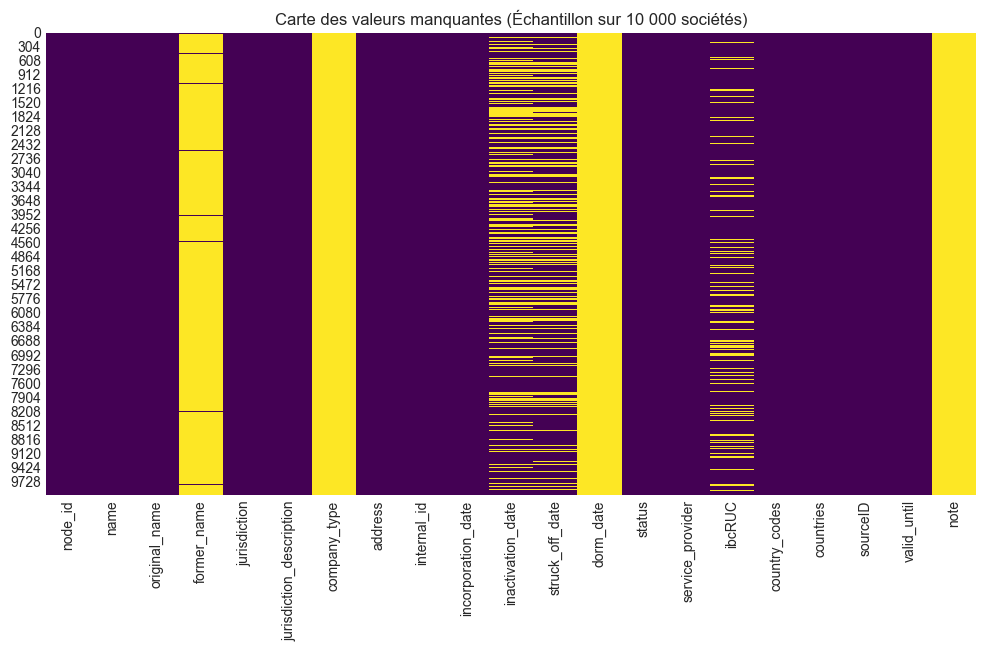

In [51]:
# 1.A.1 - Taux de valeurs manquantes
# TODO: Calculer et visualiser les NaN pour chaque fichier

# 1. Calcul du pourcentage de valeurs manquantes
# On prend notre tableau 'entities', on cherche les vides, on fait la moyenne et on met en pourcentage
pourcentages = (entities.isnull().mean() * 100).round(2)

print("Pourcentage de trous par colonne :")
# On n'affiche que les colonnes qui ont des trous, triées de la pire à la meilleure
print(pourcentages[pourcentages > 0].sort_values(ascending=False))

# 2. Création de la Heatmap (Carte de chaleur)
plt.figure(figsize=(12, 6)) # On définit la taille de l'image (largeur, hauteur)

# On dessine la carte sur les 10 000 premières lignes (pour que l'ordi ne rame pas trop)
sns.heatmap(entities.head(10000).isnull(), cbar=False, cmap='viridis')

plt.title("Carte des valeurs manquantes (Échantillon sur 10 000 sociétés)")
plt.show() # On affiche le résultat final



In [6]:
# 1.A.2 - Doublons exacts
# TODO: Compter les doublons dans chaque DataFrame

# Pour faire propre et ne pas réécrire 4 fois la même chose, 
# on regroupe nos tableaux dans un "dictionnaire"
mes_tableaux = {
    "Entités": entities,
    "Officiers": officers,
    "Intermédiaires": intermediaries,
    "Adresses": addresses
}

print("=== Analyse des doublons exacts ===")

# On fait une boucle : on va vérifier chaque tableau un par un
for nom, df in mes_tableaux.items():
    
    # 1. On compte le nombre de doublons
    nb_doublons = df.duplicated().sum()
    
    # 2. On calcule le pourcentage que ça représente
    total_lignes = len(df)
    pourcentage = (nb_doublons / total_lignes) * 100
    
    # 3. On affiche le résultat de façon propre
    print(f"{nom} : {nb_doublons} doublons trouvés ({pourcentage:.4f} %)")



=== Analyse des doublons exacts ===
Entités : 0 doublons trouvés (0.0000 %)
Officiers : 0 doublons trouvés (0.0000 %)
Intermédiaires : 0 doublons trouvés (0.0000 %)
Adresses : 0 doublons trouvés (0.0000 %)


In [52]:
# 1.A.3 - Doublons flous avec rapidfuzz
from rapidfuzz import fuzz, process

# TODO: Identifier les noms d'entités avec similarité > 90%
# Attention : échantillonner pour éviter O(n²)

print("=== Recherche de doublons flous (Similarité > 90%) ===")

# 1. On prend un échantillon de 2000 noms d'entités au hasard pour ne pas faire planter le PC
# dropna() enlève les cases vides, tolist() transforme la colonne en simple liste de mots
noms_echantillon = entities['name'].dropna().sample(n=2000, random_state=42).tolist()

doublons_trouves = []

# 2. On prend les 100 premiers noms de notre échantillon pour chercher leurs "sosies"
for nom_cible in noms_echantillon[:100]:
    
    # process.extract cherche les mots les plus proches de 'nom_cible' dans notre liste
    # score_cutoff=90 : on ne garde que ceux qui se ressemblent à plus de 90%
    # limit=2 : on veut le top 2 (car le 1er résultat sera toujours le mot exact lui-même à 100%)
    resultats = process.extract(nom_cible, noms_echantillon, scorer=fuzz.ratio, score_cutoff=90, limit=2)
    
    # Si on trouve plus d'un résultat, ça veut dire qu'on a trouvé un sosie !
    if len(resultats) > 1:
        # resultats[1] contient le sosie (le [0] étant le mot d'origine)
        sosie = resultats[1][0]
        score = resultats[1][1]
        
        # On vérifie que le sosie n'est pas le mot strictement exact
        if nom_cible != sosie:
            doublons_trouves.append((nom_cible, sosie, score))

# 3. Affichage des résultats
if len(doublons_trouves) == 0:
    print("Aucun doublon flou trouvé dans cet échantillon.")
else:
    print(f"Trouvé {len(doublons_trouves)} exemples de doublons potentiels :")
    for original, sosie, score in doublons_trouves:
        print(f"Original : '{original}'")
        print(f"Sosie    : '{sosie}' (Ressemblance : {score:.1f}%)\n")



=== Recherche de doublons flous (Similarité > 90%) ===
Trouvé 3 exemples de doublons potentiels :
Original : 'PASS ENTERPRISES INC.'
Sosie    : 'OPAL ENTERPRISES INC.' (Ressemblance : 90.5%)

Original : 'MC MULLEN PROPERTY INC'
Sosie    : 'MCMULLEN PROPERTY INC.' (Ressemblance : 95.5%)

Original : 'APEX INTERNATIONAL LTD'
Sosie    : 'CAREX INTERNATIONAL LTD.' (Ressemblance : 91.3%)



In [53]:
# 1.A.4 - Incohérences temporelles
# TODO: Trouver incorporation_date > inactivation_date, dates futures, dates < 1900

# 1. On s'assure que Python comprend bien que ce sont des dates 
entities['incorporation_date'] = pd.to_datetime(entities['incorporation_date'], errors='coerce')

# ASTUCE DE DATA SCIENTIST : On s'adapte aux colonnes qui existent vraiment dans ton fichier
colonnes_fin = []
if 'inactivation_date' in entities.columns:
    entities['inactivation_date'] = pd.to_datetime(entities['inactivation_date'], errors='coerce')
    colonnes_fin.append('inactivation_date')
if 'closed_date' in entities.columns:
    entities['closed_date'] = pd.to_datetime(entities['closed_date'], errors='coerce')
    colonnes_fin.append('closed_date')
if 'struck_off_date' in entities.columns:
    entities['struck_off_date'] = pd.to_datetime(entities['struck_off_date'], errors='coerce')
    colonnes_fin.append('struck_off_date')

# 2. Recherche des dates dans le futur
date_daujourdhui = pd.Timestamp.now()
dates_futures = entities[entities['incorporation_date'] > date_daujourdhui]

# 3. Recherche des dates avant 1900
dates_anciennes = entities[entities['incorporation_date'].dt.year < 1900]

# 4. Recherche des sociétés fermées avant d'être créées
fermees_avant_creation = pd.DataFrame() # Tableau vide par défaut

# S'il a trouvé au moins une colonne de fin d'activité, on fait la vérification
if len(colonnes_fin) > 0:
    conditions = []
    for col in colonnes_fin:
        # On vérifie si la date de fin est plus petite (plus ancienne) que la date de création
        conditions.append(entities[col] < entities['incorporation_date'])
    
    # On combine les conditions avec un OU logique (|)
    condition_finale = conditions[0]
    for cond in conditions[1:]:
        condition_finale = condition_finale | cond
        
    fermees_avant_creation = entities[condition_finale]

# 5. Affichage des résultats
print("=== Audit des Incohérences Temporelles ===")
print(f"Sociétés créées dans le futur : {len(dates_futures)}")
print(f"Sociétés créées avant 1900    : {len(dates_anciennes)}")
print(f"Fermées avant leur création   : {len(fermees_avant_creation)}")

# Petit Bonus
if len(fermees_avant_creation) > 0:
    print("\nExemples d'incohérence (Fermée avant création) :")
    colonnes_a_afficher = ['name', 'incorporation_date'] + colonnes_fin
    display(fermees_avant_creation[colonnes_a_afficher].head(3))



=== Audit des Incohérences Temporelles ===
Sociétés créées dans le futur : 5
Sociétés créées avant 1900    : 4
Fermées avant leur création   : 101

Exemples d'incohérence (Fermée avant création) :


,name,incorporation_date,inactivation_date,struck_off_date
6428,HUGE KEY DEVELOPMENT LIMITED (H.K. CO.),1992-12-13,1992-12-10,1994-03-13
7536,VEGA ENTERPRISES INC.,1981-02-26,1967-08-19,1982-05-26
11986,RIVOLI INVESTMENTS S.A.,1985-03-15,1985-03-14,1986-06-15


### 📝 Livrable 1.A : Rapport de qualité

*Résumez vos observations ici :*

- Taux de NaN global : ...
- Nombre de doublons : ...
- Incohérences détectées : ...
- Stratégie de nettoyage proposée : ...

---
## Question 1.B — Cartographie temporelle des créations

**Objectif** : Comprendre l'évolution historique de l'industrie offshore.

In [54]:
# 1.B.1 - Parser les dates d'incorporation
entities['incorporation_date'] = pd.to_datetime(
    entities['incorporation_date'], 
    errors='coerce'
)

entities['year'] = entities['incorporation_date'].dt.year

print(f"Dates valides : {entities['year'].notna().sum():,}")
print(f"Plage : {entities['year'].min():.0f} - {entities['year'].max():.0f}")


Dates valides : 788,470
Plage : 199 - 2812


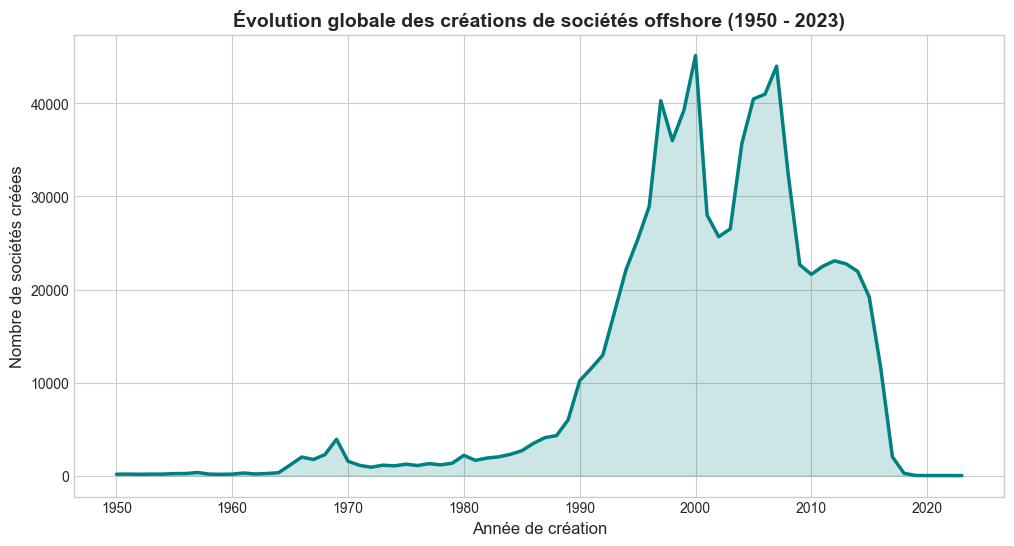

In [55]:
# 1.B.2 - Courbe globale des créations par année
# TODO: Tracer le nombre de créations par année

#  On nettoie pour le graphique : on ignore les erreurs (avant 1950 et après 2023)
annees_valides = entities[(entities['year'] >= 1950) & (entities['year'] <= 2023)]

#  On compte combien de sociétés ont été créées CHAQUE année
# value_counts() compte, sort_index() remet les années dans l'ordre chronologique (1950, 1951, 1952...)
creations_par_annee = annees_valides['year'].value_counts().sort_index()

#  Création du graphique (Line plot)
plt.figure(figsize=(12, 6))

# sns.lineplot trace une ligne reliant les points (Année en X, Nombre en Y)
sns.lineplot(x=creations_par_annee.index, y=creations_par_annee.values, linewidth=2.5, color='teal')

# Décoration du graphique
plt.title("Évolution globale des créations de sociétés offshore (1950 - 2023)", fontsize=14, fontweight='bold')
plt.xlabel("Année de création", fontsize=12)
plt.ylabel("Nombre de sociétés créées", fontsize=12)

# On ajoute un remplissage sous la courbe pour faire plus joli
plt.fill_between(creations_par_annee.index, creations_par_annee.values, color='teal', alpha=0.2)

plt.show()



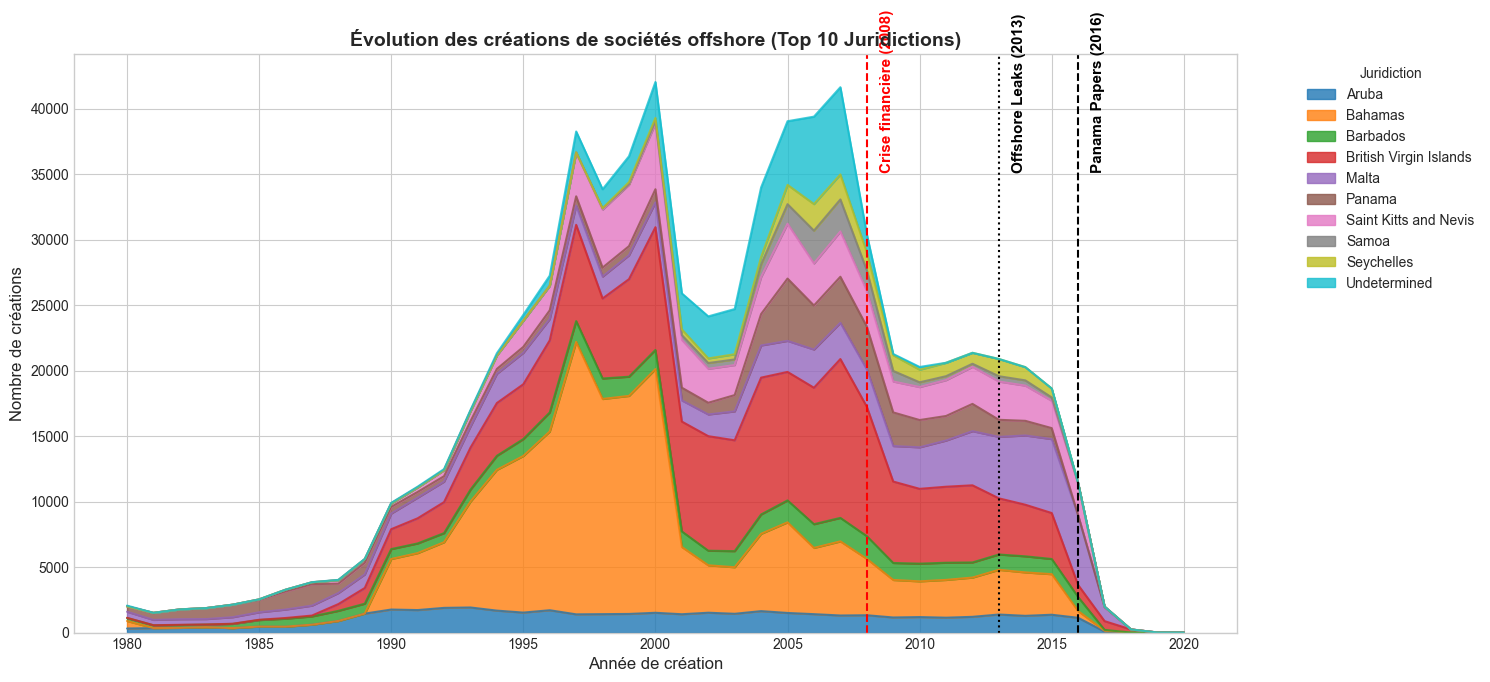

In [56]:
# 1.B.3 - Stacked area chart par juridiction (top 10)
# TODO: Visualisation multi-couches avec annotations des événements clés
# (crises financières, changements réglementaires, scandales)

# 1. Identifier le Top 10 des juridictions qui ont créé le plus d'entités au total
top_10_jur = entities['jurisdiction_description'].value_counts().head(10).index
# .index permet de récupérer juste les noms des pays (ex: ['British Virgin Islands', 'Panama'...])


# 2. Filtrer les données
# isin() vérifie si le pays fait partie du Top 10. 
# On se concentre sur la période 1980 - 2020 pour bien voir les détails.
df_top10 = entities[
    (entities['jurisdiction_description'].isin(top_10_jur)) & 
    (entities['year'] >= 1980) & 
    (entities['year'] <= 2020)
]

# 3. Préparer les données (Le fameux "Pivot")
# groupby compte les créations par année ET par pays.
# unstack() transforme le résultat pour avoir les Années en lignes et les Pays en colonnes.
pivot_data = df_top10.groupby(['year', 'jurisdiction_description']).size().unstack(fill_value=0)

# 4. Tracer le graphique en aires empilées
plt.figure(figsize=(15, 7))
# plot.area() est la fonction Pandas pour empiler les courbes
pivot_data.plot.area(cmap='tab10', alpha=0.8, ax=plt.gca())

# 5. Ajouter les annotations des événements historiques clés
# axvline trace une ligne verticale à l'année donnée
plt.axvline(x=2008, color='red', linestyle='--', linewidth=1.5)
plt.text(2008.5, plt.ylim()[1]*0.8, 'Crise financière (2008)', color='red', fontsize=11, fontweight='bold', rotation=90)

plt.axvline(x=2013, color='black', linestyle=':', linewidth=1.5)
plt.text(2013.5, plt.ylim()[1]*0.8, 'Offshore Leaks (2013)', color='black', fontsize=11, fontweight='bold', rotation=90)

plt.axvline(x=2016, color='black', linestyle='--', linewidth=1.5)
plt.text(2016.5, plt.ylim()[1]*0.8, 'Panama Papers (2016)', color='black', fontsize=11, fontweight='bold', rotation=90)

# 6. Finitions du graphique
plt.title("Évolution des créations de sociétés offshore (Top 10 Juridictions)", fontsize=14, fontweight='bold')
plt.xlabel("Année de création", fontsize=12)
plt.ylabel("Nombre de créations", fontsize=12)
# On sort la légende du graphique pour ne pas cacher les courbes
plt.legend(title='Juridiction', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajuste les marges automatiquement
plt.show()


### 📝 Livrable 1.B : Analyse des tendances

*Décrivez les tendances observées et les corrélations avec les événements :*



---
## Question 1.C — Analyse comparative des juridictions

**Objectif** : Profiler les différentes juridictions offshore.

In [11]:
# 1.C.1 - Métriques par juridiction
# TODO: Calculer n_entities, n_officers, ratio_officers_entities, avg_lifetime_days, pct_active

# 1. On convertit en dates
entities['incorporation_date'] = pd.to_datetime(entities['incorporation_date'], errors='coerce')
entities['closed_date'] = pd.to_datetime(entities.get('closed_date', np.nan), errors='coerce')

# --- LE CORRECTIF EST ICI ---
# On supprime TOUTES les dates absurdes (Avant 1900 ou Après 2030)
# Le symbole | veut dire "OU"
mask_inc_out = (entities['incorporation_date'].dt.year > 2030) | (entities['incorporation_date'].dt.year < 1900)
entities.loc[mask_inc_out, 'incorporation_date'] = pd.NaT

mask_clo_out = (entities['closed_date'].dt.year > 2030) | (entities['closed_date'].dt.year < 1900)
entities.loc[mask_clo_out, 'closed_date'] = pd.NaT
# -----------------------------

# On définit l'activité
entities['is_active'] = entities['incorporation_date'].notna() & entities['closed_date'].isna()

# 2. Calcul de la durée de vie (cette fois on est totalement protégés !)
entities['lifetime_days'] = (entities['closed_date'] - entities['incorporation_date']).dt.days
entities.loc[entities['lifetime_days'] < 0, 'lifetime_days'] = np.nan

# 3. Statistiques de base (Volume, Actives, Durée de vie)
base_stats = entities.groupby('jurisdiction_description').agg(
    n_entities=('node_id', 'count'),
    n_active=('is_active', 'sum'),
    avg_lifetime_days=('lifetime_days', 'mean')
).reset_index()

base_stats['pct_active'] = (base_stats['n_active'] / base_stats['n_entities']) * 100

# 4. LE CROISEMENT AVEC LES RELATIONS (Pour trouver le nombre d'officiers)
ent_jur = entities[['node_id', 'jurisdiction_description']]
rels_merged = relationships.merge(ent_jur, left_on='node_id_end', right_on='node_id', how='inner')

officers_per_jur = rels_merged.groupby('jurisdiction_description').agg(
    n_officers=('node_id_start', 'nunique')
).reset_index()

# 5. On assemble tout le profil final
jur_stats = base_stats.merge(officers_per_jur, on='jurisdiction_description', how='left')
jur_stats['n_officers'] = jur_stats['n_officers'].fillna(0)

# 6. Calcul du fameux RATIO demandé
jur_stats['ratio_officers_entities'] = jur_stats['n_officers'] / jur_stats['n_entities']

# On filtre pour ne garder que les vrais paradis fiscaux (plus de 1000 sociétés)
jur_stats_top = jur_stats[jur_stats['n_entities'] > 1000].sort_values(by='n_entities', ascending=False)

print("=== Profil des juridictions (avec ratio Officiers/Entités) ===")
display(jur_stats_top.head(10))

=== Profil des juridictions (avec ratio Officiers/Entités) ===


,jurisdiction_description,n_entities,n_active,avg_lifetime_days,pct_active,n_officers,ratio_officers_entities
5,Bahamas,209713,208842,NaN,99.584670,54793.0,0.261276
10,British Virgin Islands,172389,170442,NaN,98.870578,240893.0,1.397380
44,Malta,83939,83571,NaN,99.561586,107340.0,1.278786
61,Saint Kitts and Nevis,70604,70568,NaN,99.949011,365.0,0.005170
77,Undetermined,53571,44117,NaN,82.352392,37966.0,0.708704
3,Aruba,49050,49047,NaN,99.993884,33930.0,0.691743
57,Panama,48691,48532,NaN,99.673451,66634.0,1.368508
6,Barbados,40846,40645,NaN,99.507908,128907.0,3.155927
65,Seychelles,16886,15961,NaN,94.522089,27389.0,1.621995
64,Samoa,15019,13421,NaN,89.360144,27056.0,1.801451


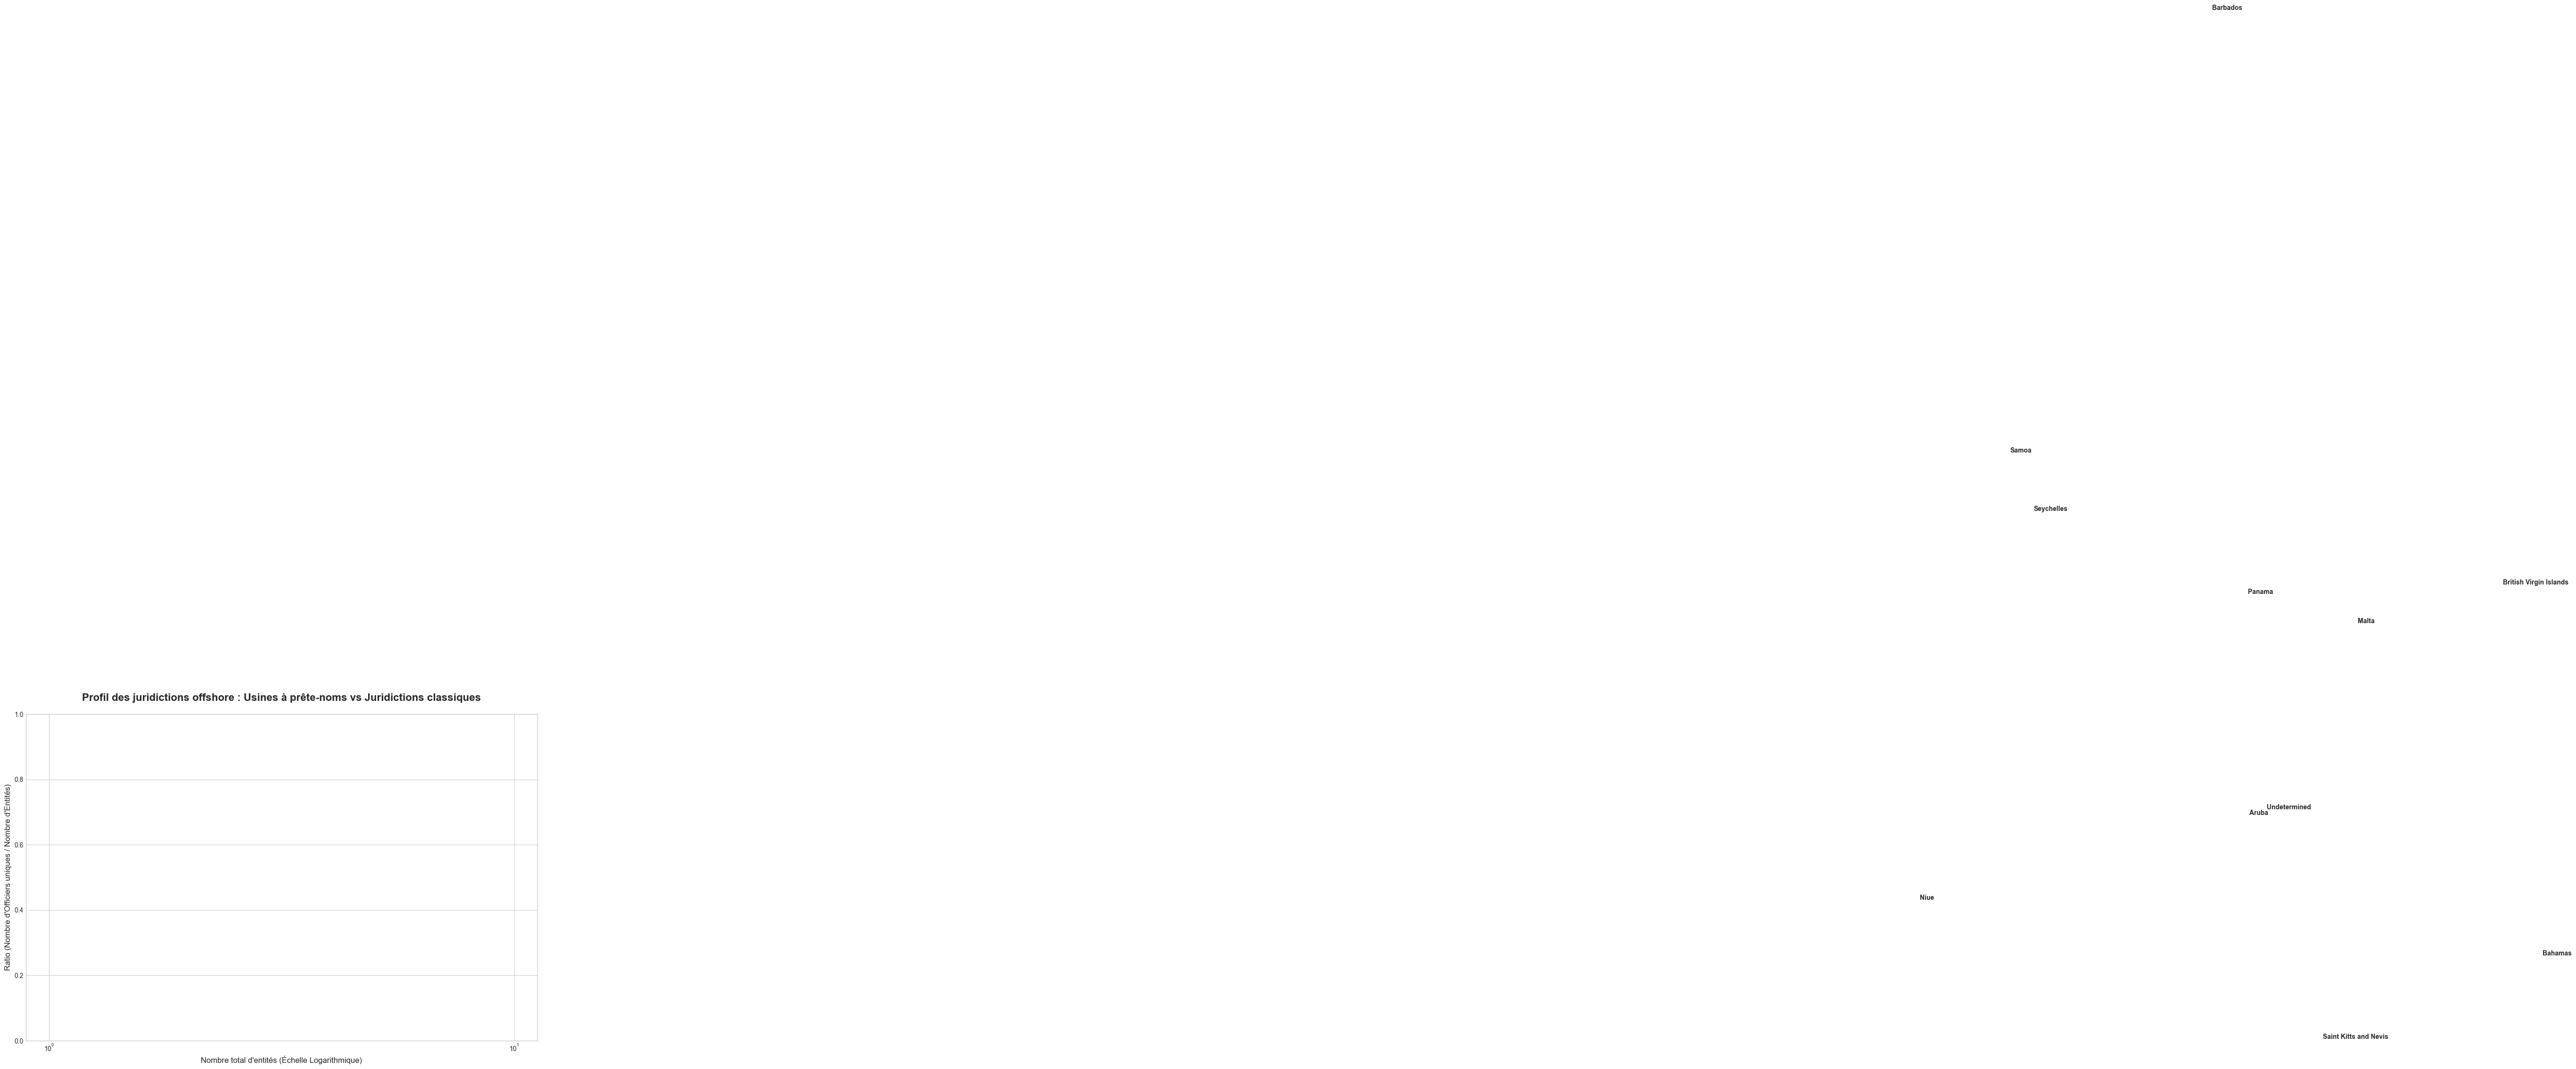

In [57]:
# 1.C.2 - Scatter plot des juridictions
# X: nombre d'entités (log), Y: ratio officers/entités, Taille: nb intermédiaires, Couleur: durée de vie
# TODO

plt.figure(figsize=(14, 9))

# Création du nuage de points avec Seaborn
scatter = sns.scatterplot(
    data=jur_stats_top,
    x='n_entities',               # Axe X : Nombre d'entités
    y='ratio_officers_entities',  # Axe Y : Le fameux ratio calculé
    size='pct_active',            # Taille : Pourcentage d'activité (adaptation)
    hue='avg_lifetime_days',      # Couleur : Durée de vie moyenne
    sizes=(100, 1200),            # Taille min et max des bulles
    palette='coolwarm',           # Palette de couleurs (Bleu = court, Rouge = long)
    alpha=0.8,
    edgecolor='black'
)

# Passage de l'axe X en échelle logarithmique (très important vu les volumes)
plt.xscale('log')

# Ajout des étiquettes de texte pour identifier les points
for i, row in jur_stats_top.iterrows():
    # On ajoute le texte uniquement pour les très grosses juridictions ou celles avec un ratio très faible
    if row['n_entities'] > 10000 or row['ratio_officers_entities'] < 0.5:
        plt.text(
            row['n_entities'] * 1.1, # Décalage à droite pour ne pas écrire SUR le point
            row['ratio_officers_entities'], 
            row['jurisdiction_description'], 
            fontsize=10,
            fontweight='bold'
        )

# Décorations du graphique
plt.title("Profil des juridictions offshore : Usines à prête-noms vs Juridictions classiques", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Nombre total d'entités (Échelle Logarithmique)", fontsize=12)
plt.ylabel("Ratio (Nombre d'Officiers uniques / Nombre d'Entités)", fontsize=12)

# Ajustement de la légende
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

plt.show()


### 📝 Livrable 1.C : Juridictions "industrialisées

*Identifiez les juridictions avec beaucoup d'entités et peu d'officers uniques :*



---
## Question 1.D — Profilage des intermédiaires

**Objectif** : Identifier et caractériser les acteurs clés.

In [58]:
# 1.D.1 - Jointure intermédiaires -> entités
inter_rels = relationships[relationships['rel_type'] == 'intermediary_of']
print(f"Relations intermediary_of : {len(inter_rels):,}")

inter_rels = relationships[relationships['rel_type'] == 'intermediary_of']
print(f"Relations intermediary_of : {len(inter_rels):,}")

# On récupère le NOM de l'intermédiaire
inter_noms = intermediaries[['node_id', 'name']].rename(columns={'name': 'intermediary_name'})
merged_1 = inter_rels.merge(inter_noms, left_on='node_id_start', right_on='node_id', how='inner')

# On récupère la JURIDICTION de l'entité qu'il a créée
ent_jur = entities[['node_id', 'jurisdiction_description']]

# C'EST ICI QU'ON CRÉE LA VARIABLE MANQUANTE !
df_inter_full = merged_1.merge(ent_jur, left_on='node_id_end', right_on='node_id', how='inner')

print(f"Jointure réussie ! Données prêtes pour le graphique : {len(df_inter_full):,} lignes.")


Relations intermediary_of : 598,546
Relations intermediary_of : 598,546
Jointure réussie ! Données prêtes pour le graphique : 590,096 lignes.


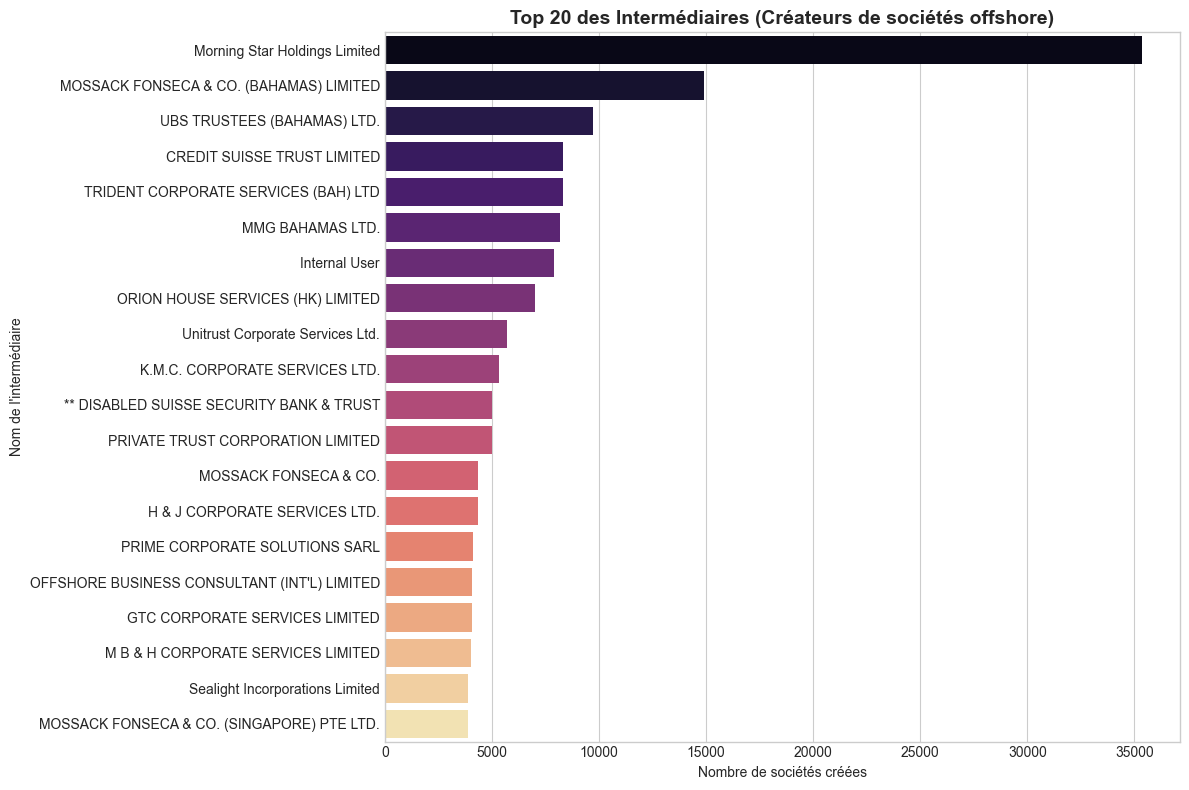

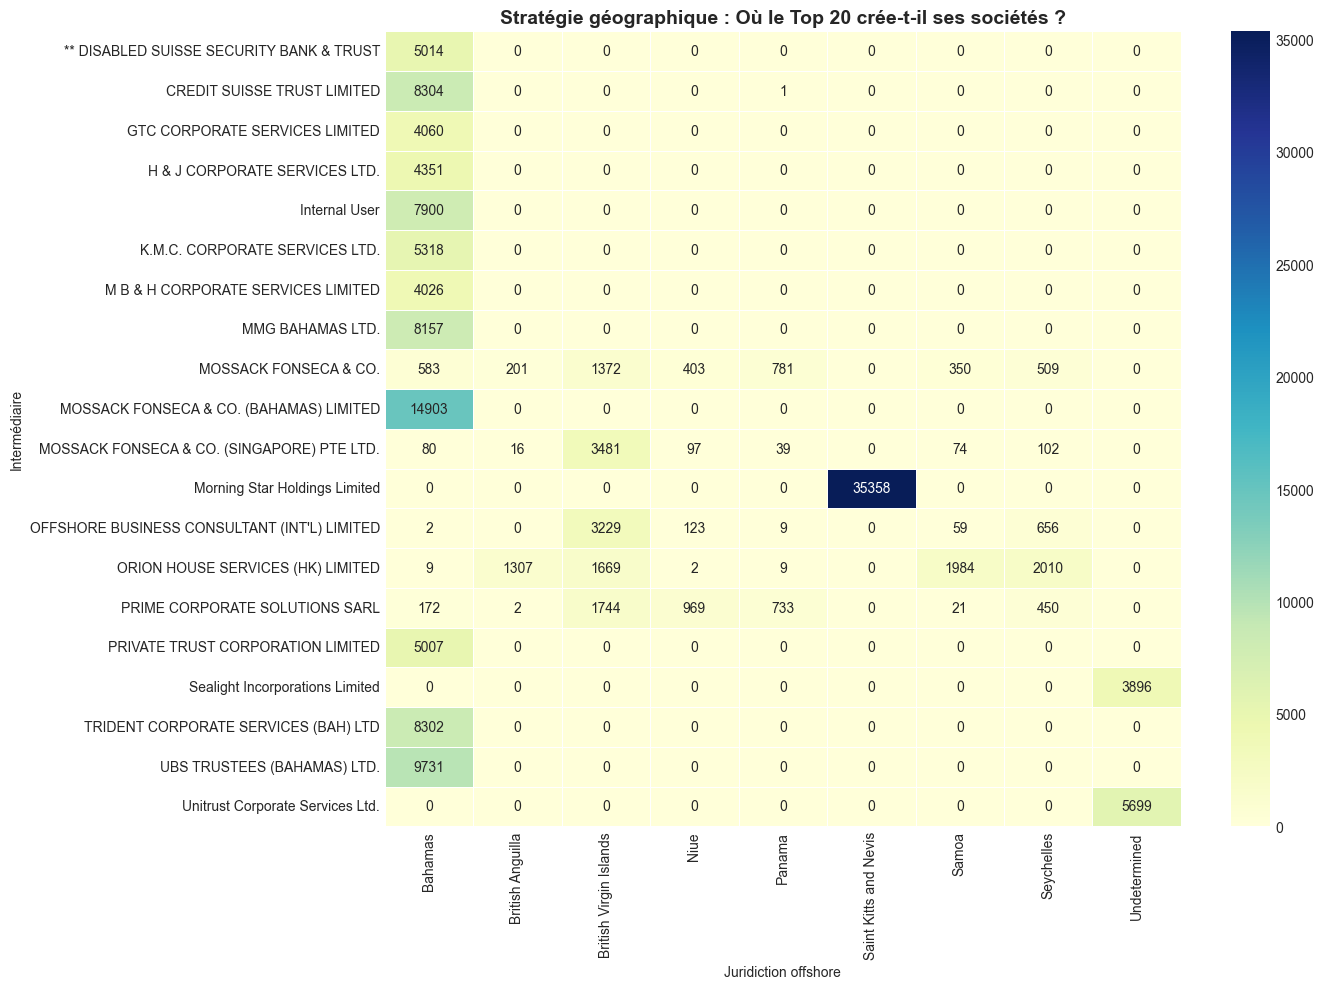

In [59]:
# 1.D.2 - Top 20 intermédiaires
# TODO: Bar chart horizontal + Heatmap intermédiaire × juridiction

# --- GRAPHIQUE 1 : LE CLASSEMENT ---
top_20_inter = df_inter_full['intermediary_name'].value_counts().head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_inter.values, y=top_20_inter.index, palette='magma')
plt.title("Top 20 des Intermédiaires (Créateurs de sociétés offshore)", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de sociétés créées")
plt.ylabel("Nom de l'intermédiaire")
plt.tight_layout()
plt.show()

# --- GRAPHIQUE 2 : LA HEATMAP GEOGRAPHIQUE ---
top_10_jur_inter = df_inter_full['jurisdiction_description'].value_counts().head(10).index

df_heatmap = df_inter_full[
    (df_inter_full['intermediary_name'].isin(top_20_inter.index)) &
    (df_inter_full['jurisdiction_description'].isin(top_10_jur_inter))
]

pivot_inter_jur = df_heatmap.groupby(['intermediary_name', 'jurisdiction_description']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_inter_jur, cmap='YlGnBu', linewidths=.5, annot=True, fmt='d')
plt.title("Stratégie géographique : Où le Top 20 crée-t-il ses sociétés ?", fontsize=14, fontweight='bold')
plt.xlabel("Juridiction offshore")
plt.ylabel("Intermédiaire")
plt.tight_layout()
plt.show()


### 📝 Livrable 1.D : Fiches profil top 10 intermédiaires

*Mossack Fonseca est-il vraiment #1 ?*



---
## Question 1.E — Détection d'anomalies dans les noms

**Objectif** : Identifier des patterns suspects.

In [60]:
import re
from unidecode import unidecode

# 1.E.1 - Noms génériques
generic_patterns = [
    r'^(Global|International|Universal|World)\s+(Holdings|Investment|Trading)',
    r'^[A-Z]{2,4}\s+(Ltd|LLC|Corp|Inc)\.?$',  # "ABC Ltd"
    r'(Nominee|Proxy|Bearer)',
]

# TODO: Détecter les entités correspondant à ces patterns

print("=== Recherche de noms suspects ===")

# Les "motifs" fournis par le prof
generic_patterns = [
    r'^(Global|International|Universal|World)\s+(Holdings|Investment|Trading)',
    r'^[A-Z]{2,4}\s+(Ltd|LLC|Corp|Inc)\.?$',  # Exemple: "ABC Ltd"
    r'(Nominee|Proxy|Bearer)'                 # Mots indiquant un prête-nom
]

# On combine toutes ces règles en une seule grande règle (avec le symbole | qui veut dire OU)
regle_combinee = '|'.join(generic_patterns)

# On fouille la colonne 'name' de nos entités.
# na=False évite que le code plante s'il y a des cases vides
# flags=re.IGNORECASE permet de chercher en majuscule comme en minuscule
entites_suspectes = entities[entities['name'].str.contains(regle_combinee, flags=re.IGNORECASE, regex=True, na=False)]

print(f"Entités avec un nom générique/suspect : {len(entites_suspectes):,}")

# On affiche 5 exemples au hasard pour voir à quoi ça ressemble
if len(entites_suspectes) > 0:
    print("\nExemples de noms suspects :")
    display(entites_suspectes[['name', 'jurisdiction_description']].sample(5))



=== Recherche de noms suspects ===
Entités avec un nom générique/suspect : 5,228

Exemples de noms suspects :


,name,jurisdiction_description
416755,KIO INC,Bahamas
368837,FOFI LTD,Bahamas
647637,BEER INC.,Saint Kitts and Nevis
508223,Oak Nominees Limited,Isle of Man
95795,Gulf Nominees Ltd.,British Virgin Islands


In [61]:
# 1.E.2 - Near-duplicates et caractères suspects
# TODO: Détecter homoglyphes (О cyrillique vs O latin)

# L'alphabet Cyrillique (Russe) a des lettres comme le 'О' ou le 'А' qui sont visuellement identiques au 'O' et 'A' latin, mais l'ordinateur les voit différemment.
# On va chercher si des mots contiennent des caractères de l'alphabet cyrillique.
# Le code [\u0400-\u04FF] représente toutes les lettres russes en informatique.

# On a enlevé le 'r' devant les guillemets pour que l'unicode fonctionne avec PyArrow
homoglyphes = entities[entities['name'].str.contains('[\u0400-\u04FF]', regex=True, na=False)]

print(f"\nEntités contenant des caractères cyrilliques (Homoglyphes potentiels) : {len(homoglyphes):,}")

if len(homoglyphes) > 0:
    print("\nExemples avec caractères suspects :")
    display(homoglyphes[['name']].head(5))




Entités contenant des caractères cyrilliques (Homoglyphes potentiels) : 3

Exemples avec caractères suspects :


,name
803877,NBС INTERNATIONAL AG
804386,ANVAR СORP
804696,ITС IMPEX GMBH


---
# 🕸️ PARTIE 2 : Analyse de réseau

```
relationships.csv → NetworkX Graph → Métriques → Communautés
```

## Question 2.A — Construction et métriques du graphe

**Objectif** : Construire le graphe et calculer ses propriétés globales.

In [62]:
# 2.A.1 - Construction du graphe
G = nx.Graph()

# Ajout des nœuds avec attributs
print("Ajout des entités(sociétés)...")
for _, row in tqdm(entities.iterrows(), total=len(entities)):
    G.add_node(row['node_id'], 
               type='entity', 
               name=row['name'],
               jurisdiction=row.get('jurisdiction', None))

# TODO: Ajouter officers, intermediaries, addresses

print("Ajout des officiers(personnes)...")
for _, row in tqdm(officers.iterrows(), total=len(officers)):
    G.add_node(row['node_id'],
               type='officer',
               name=row.get('name', ''), 
               country=row.get('countries', ''))

print("Ajout des intermédiaires...")
for _, row in tqdm(intermediaries.iterrows(), total=len(intermediaries)):
    G.add_node(row['node_id'], 
               type='intermediary', 
               name=row.get('name', ''))

print("Ajout des adresses...")
for _, row in tqdm(addresses.iterrows(), total=len(addresses)):
    G.add_node(row['node_id'], 
               type='address', 
               address=row.get('address', ''))

print(f"\nTotal des Nœuds dans le réseau : {G.number_of_nodes():,}")


Ajout des entités(sociétés)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 814344/814344 [01:16<00:00, 10667.04it/s]


Ajout des officiers(personnes)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 771315/771315 [01:06<00:00, 11581.89it/s]


Ajout des intermédiaires...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25629/25629 [00:02<00:00, 12450.98it/s]


Ajout des adresses...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 402246/402246 [00:39<00:00, 10175.81it/s]


Total des Nœuds dans le réseau : 2,013,534


In [63]:
# 2.A.2 - Ajout des arêtes
print("\nAjout des relations(les câbles entre les points)...")
for _, row in tqdm(relationships.iterrows(), total=len(relationships)):
    # On tire un trait entre le point de départ et le point d'arrivée
    G.add_edge(row['node_id_start'], row['node_id_end'], rel_type=row['rel_type'])

print(f"Total des Arêtes dans le réseau : {G.number_of_edges():,}")


Ajout des relations(les câbles entre les points)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3339267/3339267 [05:02<00:00, 11028.95it/s]


Total des Arêtes dans le réseau : 2,896,167


In [64]:
# 2.A.3 - Métriques globales
print("=== MÉTRIQUES DU GRAPHE ===")
print(f"Nombre de nœuds : {G.number_of_nodes():,}")
print(f"Nombre d'arêtes : {G.number_of_edges():,}")

# La densité = Nombre de liens existants divisé par le nombre de liens possibles. 
# Dans la vraie vie, on ne connaît pas tout le monde, donc c'est très proche de 0.
print(f"Densité : {nx.density(G):.8f}")

# Composantes connexes = Le nombre de "petits îlots" déconnectés les uns des autres.
print(f"Composantes connexes : {nx.number_connected_components(G):,}")

=== MÉTRIQUES DU GRAPHE ===
Nombre de nœuds : 2,016,523
Nombre d'arêtes : 2,896,167
Densité : 0.00000142
Composantes connexes : 33,426


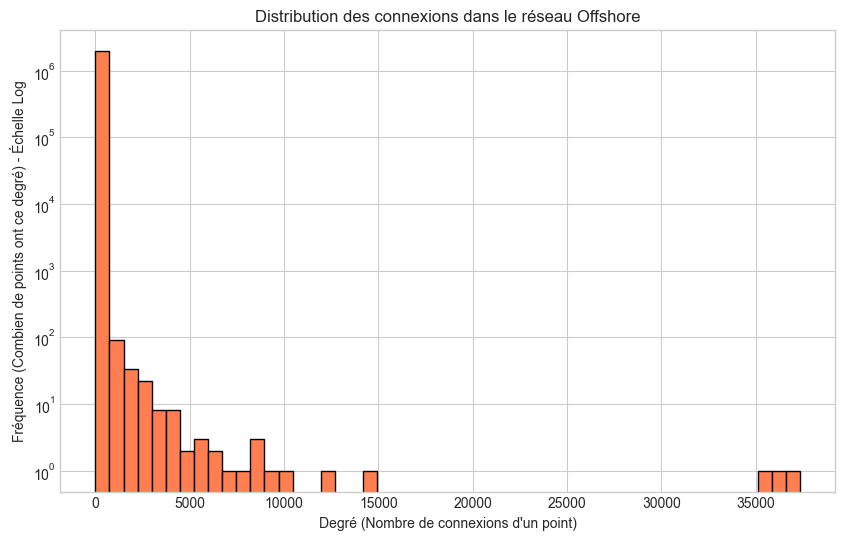

Degré moyen : 2.87 connexions par nœud
Degré max (Le 'Boss' du réseau) : 37338 connexions !!!!!!!!


In [65]:
# 2.A.4 - Distribution des degrés
# Le "degré" d'un nœud, c'est le nombre de liens qu'il possède. (Ex: Un mec avec 50 sociétés a un degré de 50).
degrees = [d for n, d in G.degree()]

plt.figure(figsize=(10, 6))
# On trace un histogramme en échelle Log, car 99% des gens ont 1 ou 2 liens, et 1% en a 10 000 !
plt.hist(degrees, bins=50, log=True, edgecolor='black', color='coral')
plt.xlabel('Degré (Nombre de connexions d\'un point)')
plt.ylabel('Fréquence (Combien de points ont ce degré) - Échelle Log')
plt.title('Distribution des connexions dans le réseau Offshore')
plt.show()

print(f"Degré moyen : {np.mean(degrees):.2f} connexions par nœud")
print(f"Degré max (Le 'Boss' du réseau) : {np.max(degrees)} connexions !!!!!!!!")

---
## Question 2.B — Identification des hubs (centralité)

**Objectif** : Trouver les nœuds les plus importants.

In [66]:
# 2.B.1 - Centralité de degré

# 1. On calcule le score de centralité de chaque point (entre 0 et 1)
degree_cent = nx.degree_centrality(G)

# 2. On trie le dictionnaire pour trouver les 50 plus gros scores
# x[1] veut dire qu'on trie par la valeur du score, pas par l'ID du nœud
top_nodes = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:50]

print("\n=== TOP 10 DES NŒUDS LES PLUS CONNECTÉS (LES HUBS) ===")
for node_id, cent in top_nodes[:10]:
    # On récupère les étiquettes qu'on avait collées sur les nœuds à l'étape d'avant
    node_type = G.nodes[node_id].get('type', 'Inconnu')
    node_name = str(G.nodes[node_id].get('name', 'N/A'))[:50] # On coupe à 50 caractères si c'est trop long
    print(f"Score: {cent:.6f} | Type: {node_type:12} | Nom: {node_name}")


=== TOP 10 DES NŒUDS LES PLUS CONNECTÉS (LES HUBS) ===
Score: 0.018516 | Type: address      | Nom: N/A
Score: 0.017979 | Type: officer      | Nom: Portcullis TrustNet (BVI) Limited
Score: 0.017535 | Type: intermediary | Nom: Morning Star Holdings Limited
Score: 0.007390 | Type: intermediary | Nom: MOSSACK FONSECA & CO. (BAHAMAS) LIMITED
Score: 0.005932 | Type: address      | Nom: N/A
Score: 0.004820 | Type: intermediary | Nom: UBS TRUSTEES (BAHAMAS) LTD.
Score: 0.004596 | Type: address      | Nom: N/A
Score: 0.004244 | Type: address      | Nom: N/A
Score: 0.004117 | Type: intermediary | Nom: CREDIT SUISSE TRUST LIMITED
Score: 0.004110 | Type: intermediary | Nom: TRIDENT CORPORATE SERVICES (BAH) LTD



Génération de la carte du réseau du N°1...
Le réseau de ce Hub est gigantesque (37,339 connexions) !
Pour ne pas faire planter l'ordinateur, on affiche un échantillon de 300 points.
Calcul de la physique des ressorts en cours...


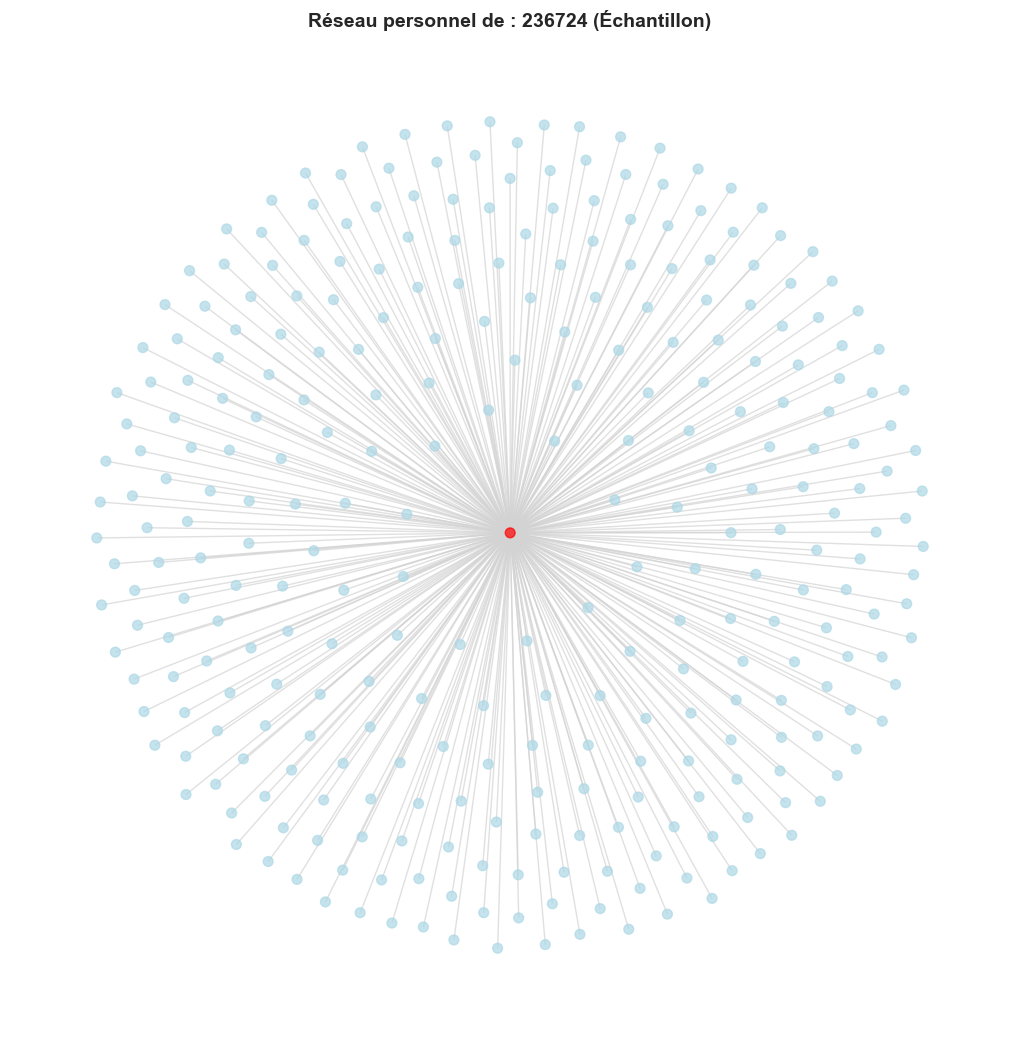

In [67]:
# 2.B.2 - Ego-network des hubs
def plot_ego_network_safe(G, node_id, radius=1, max_nodes=300):
    # 1. On extrait le "mini-réseau" complet
    ego = nx.ego_graph(G, node_id, radius=radius)
    
    # 2. SECURITE ANTI-CRASH : Si c'est trop gros, on coupe !
    if ego.number_of_nodes() > max_nodes:
        print(f"Le réseau de ce Hub est gigantesque ({ego.number_of_nodes():,} connexions) !")
        print(f"Pour ne pas faire planter l'ordinateur, on affiche un échantillon de {max_nodes} points.")
        
        # On garde le centre, et on prend juste une partie de ses voisins
        voisins = list(ego.neighbors(node_id))[:max_nodes-1]
        noeuds_a_garder = [node_id] + voisins
        ego = ego.subgraph(noeuds_a_garder)
    
    print("Calcul de la physique des ressorts en cours...")
    
    # Le calcul physique ne plantera plus ici !
    pos = nx.spring_layout(ego, k=0.15, seed=42)
    
    colors = []
    for n in ego.nodes():
        ntype = ego.nodes[n].get('type', '')
        if n == node_id: colors.append('red')           # Le Boss au centre
        elif ntype == 'entity': colors.append('lightblue') # Sociétés
        elif ntype == 'officer': colors.append('lightgreen')# Personnes
        else: colors.append('gray')                     # Reste
            
    plt.figure(figsize=(10, 10))
    nx.draw(ego, pos, node_color=colors, with_labels=False, node_size=50, alpha=0.7, edge_color='lightgray')
    
    nom_centre = str(G.nodes[node_id].get('name', node_id))[:40]
    plt.title(f"Réseau personnel de : {nom_centre} (Échantillon)", fontsize=14, fontweight='bold')
    plt.show()

# On trace le réseau du TOUT PREMIER de notre classement (le plus gros Hub !)
print("\nGénération de la carte du réseau du N°1...")
plot_ego_network_safe(G, top_nodes[0][0])


---
## Question 2.C — Détection de communautés

**Objectif** : Identifier les groupes cohérents.

In [69]:
import community as community_louvain

# 2.C.1 - Extraction de la plus grande composante connexe
largest_cc = max(nx.connected_components(G), key=len)
G_largest = G.subgraph(largest_cc).copy()

print(f"La plus grande composante contient {len(G_largest.nodes()):,} nœuds (points).")

La plus grande composante contient 942,172 nœuds (points).


In [70]:
# 2.C.2 - Algorithme de Louvain
import community as community_louvain # C'est la librairie python-louvain

print("\nRecherche des communautés...")
# L'algorithme attribue un "Numéro d'équipe" à chaque point
partition = community_louvain.best_partition(G_largest)

# La modularité (entre 0 et 1) note la qualité de notre découpage. 
# Si c'est > 0.3, c'est qu'il y a de vraies communautés solides.
modularity = community_louvain.modularity(partition, G_largest)
print(f"Modularité du réseau : {modularity:.3f}")
print(f"Nombre total de communautés (groupes) trouvées : {len(set(partition.values())):,}")


Recherche des communautés...
Modularité du réseau : 0.932
Nombre total de communautés (groupes) trouvées : 1,657


In [72]:
# 2.C.3 - Caractérisation des 5 plus grandes communautés
# TODO: Taille, % officers, % entities, top juridiction, top intermédiaire

import collections

# On compte combien de points il y a dans chaque "équipe"
community_counts = collections.Counter(partition.values())
top_5_communities = community_counts.most_common(5)

print("\n=== PROFIL DES 5 PLUS GRANDES COMMUNAUTÉS ===")
for comm_id, size in top_5_communities:
    # On récupère tous les ID des nœuds qui appartiennent à cette équipe précise
    nodes_in_comm = [node for node, comm in partition.items() if comm == comm_id]
    
    # On regarde les pays (juridictions) de ces points pour voir s'il y a une "spécialité"
    jurisdictions = [G_largest.nodes[n].get('jurisdiction') for n in nodes_in_comm if G_largest.nodes[n].get('jurisdiction')]
    
    # On cherche le pays dominant dans ce groupe
    top_jur = collections.Counter(jurisdictions).most_common(1)
    top_jur_name = top_jur[0][0] if top_jur else "Multi-juridictions"
    
    # On compte combien il y a d'officiers (personnes) dans ce groupe
    nb_officiers = sum(1 for n in nodes_in_comm if G_largest.nodes[n].get('type') == 'officer')
    pourcentage_off = (nb_officiers / size) * 100
    
    print(f"-> Communauté n°{comm_id} : {size:,} membres")
    print(f"   Spécialité géographique : {top_jur_name}")
    print(f"   Proportion d'Officiers  : {pourcentage_off:.1f}%")
    print("-" * 40)



=== PROFIL DES 5 PLUS GRANDES COMMUNAUTÉS ===
-> Communauté n°231 : 112,342 membres
   Spécialité géographique : BVI
   Proportion d'Officiers  : 37.7%
----------------------------------------
-> Communauté n°19 : 48,435 membres
   Spécialité géographique : BAH
   Proportion d'Officiers  : 20.1%
----------------------------------------
-> Communauté n°11 : 31,860 membres
   Spécialité géographique : SAM
   Proportion d'Officiers  : 38.0%
----------------------------------------
-> Communauté n°82 : 26,450 membres
   Spécialité géographique : SAM
   Proportion d'Officiers  : 43.7%
----------------------------------------
-> Communauté n°194 : 17,037 membres
   Spécialité géographique : COOK
   Proportion d'Officiers  : 45.1%
----------------------------------------


---
## Question 2.D — Patterns de prête-noms

**Objectif** : Identifier les structures suspectes.

In [73]:
# 2.D.1 - Officers connectés à > 50 entités
print("Recherche des Prête-noms (Officers avec plus de 50 connexions)...")

# On parcourt tous les points du graphe. 
# Si le point est un 'officer' ET qu'il a un degré (nombre de liens) > 50, on le garde.
suspicious_officers = [
    n for n, d in G.degree() 
    if G.nodes[n].get('type') == 'officer' and d > 50
]

print(f"Nombre de prête-noms suspects identifiés : {len(suspicious_officers)}")

# On va isoler le Top 5 pour voir à qui on a affaire
top_suspects = []
if len(suspicious_officers) > 0:
    print("\nLe Top 5 des prête-noms :")
    # On trie nos suspects par leur nombre de connexions (du plus grand au plus petit)
    top_suspects = sorted(suspicious_officers, key=lambda n: G.degree(n), reverse=True)[:5]
    for n in top_suspects:
        nom = G.nodes[n].get('name', 'Inconnu')
        degre = G.degree(n)
        print(f"- {nom} (Directeur de {degre} sociétés)")

Recherche des Prête-noms (Officers avec plus de 50 connexions)...
Nombre de prête-noms suspects identifiés : 1538

Le Top 5 des prête-noms :
- Portcullis TrustNet (BVI) Limited (Directeur de 36256 sociétés)
- Portcullis TrustNet (Samoa) Limited (Directeur de 4260 sociétés)
- MOSSFON SUBSCRIBERS LTD. (Directeur de 3890 sociétés)
- Reid Services Limited - Cayman (Directeur de 2704 sociétés)
- Sharecorp Limited (Directeur de 2682 sociétés)


In [74]:
# 2.D.2 - Analyse de la structure des officers suspects
# TODO: Classifier les officers en "étoile pure" vs "clique"
print("\nAnalyse de la structure de leur réseau")

def analyze_officer_network(G, officer_node):
    # 1. On prend tous les voisins de l'officier (les sociétés qu'il gère)
    neighbors = list(G.neighbors(officer_node))
    
    # 2. On regarde UNIQUEMENT le réseau entre ces sociétés (sans l'officier au milieu)
    subgraph = G.subgraph(neighbors)
    
    # 3. On calcule la densité de ce sous-réseau
    # Si la densité est 0, c'est que les sociétés ne font aucune affaire entre elles.
    densite = nx.density(subgraph)
    
    # 4. Classification
    if densite == 0.0:
        forme = "Étoile pure (Prête-nom professionnel évident)"
    elif densite < 0.1:
        forme = "Étoile imparfaite (Probable prête-nom)"
    else:
        forme = "Clique (Vrai groupe d'entreprises liées)"
        
    return {
        'n_entities': len(neighbors),
        'density_without_officer': densite,
        'forme': forme
    }

# On teste notre fonction d'analyse sur notre Top 5 des suspects
for n in top_suspects:
    nom = str(G.nodes[n].get('name', 'Inconnu'))[:25] # On coupe le nom s'il est trop long
    analyse = analyze_officer_network(G, n)
    
    print(f"{nom:25} | Gère {analyse['n_entities']:4} stés | Densité entre elles : {analyse['density_without_officer']:.3f} -> {analyse['forme']}")




Analyse de la structure de leur réseau
Portcullis TrustNet (BVI) | Gère 36256 stés | Densité entre elles : 0.000 -> Étoile imparfaite (Probable prête-nom)
Portcullis TrustNet (Samo | Gère 4260 stés | Densité entre elles : 0.000 -> Étoile imparfaite (Probable prête-nom)
MOSSFON SUBSCRIBERS LTD.  | Gère 3890 stés | Densité entre elles : 0.000 -> Étoile imparfaite (Probable prête-nom)
Reid Services Limited - C | Gère 2704 stés | Densité entre elles : 0.001 -> Étoile imparfaite (Probable prête-nom)
Sharecorp Limited         | Gère 2682 stés | Densité entre elles : 0.001 -> Étoile imparfaite (Probable prête-nom)


---
# 🌍 PARTIE 3 : Analyse géographique

```
PAYS D'ORIGINE (Officers) ══════▶ JURIDICTIONS (Entities)
```

## Question 3.A — Matrice origine-destination

**Objectif** : Cartographier les flux entre pays d'origine et juridictions.

In [75]:
# 3.A.1 - Construction de la matrice de flux
# TODO: Jointure officer -> entity -> juridiction + officer -> address -> pays d'origine
print("Construction des flux (Origine -> Destination)")

# 1. On ne garde que les liens "officer_of" (Un individu gère une société)
officer_rels = relationships[relationships['rel_type'] == 'officer_of']

# 2. On récupère le PAYS D'ORIGINE de l'officier
# On utilise 'countries' (ou on extrait de l'adresse si besoin, mais 'countries' est souvent rempli)
off_pays = officers[['node_id', 'countries']].rename(columns={'countries': 'pays_origine'})
# On nettoie : on enlève ceux qui n'ont pas de pays renseigné
off_pays = off_pays.dropna(subset=['pays_origine'])

# On fait le lien : Relation <-> Pays de l'officier
flux_etape1 = officer_rels.merge(off_pays, left_on='node_id_start', right_on='node_id', how='inner')

# 3. On récupère la JURIDICTION (Destination) de la société
ent_jur = entities[['node_id', 'jurisdiction_description']].rename(columns={'jurisdiction_description': 'juridiction_destination'})
ent_jur = ent_jur.dropna(subset=['juridiction_destination'])

# On fait le 2ème lien : Flux <-> Juridiction de la société
flux_final = flux_etape1.merge(ent_jur, left_on='node_id_end', right_on='node_id', how='inner')

# Comme certains officiers ont plusieurs pays séparés par des points-virgules, on nettoie en prenant juste le premier
flux_final['pays_origine'] = flux_final['pays_origine'].str.split(';').str[0]

print(f"Flux tracés avec succès : {len(flux_final):,} relations Origine-Destination.")



Construction des flux (Origine -> Destination)
Flux tracés avec succès : 1,320,332 relations Origine-Destination.



Génération de la carte de chaleur


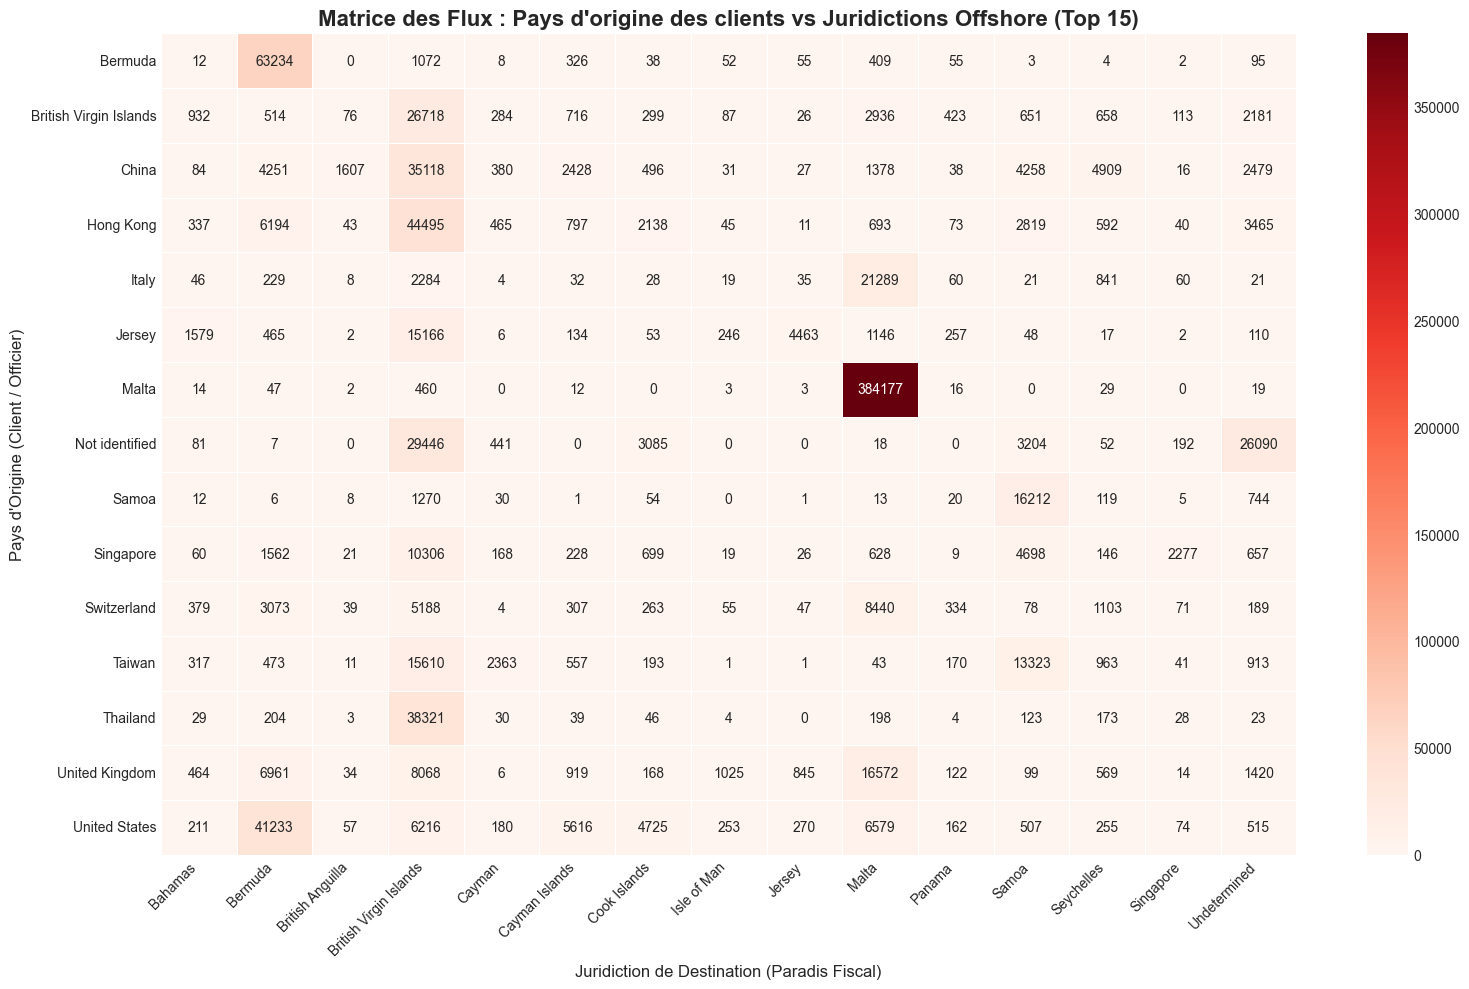

In [76]:
# 3.A.2 - Heatmap top 15 pays × top 15 juridictions
# TODO
print("\nGénération de la carte de chaleur")

# 1. On identifie le Top 15 des pays clients et le Top 15 des paradis fiscaux
top_15_origines = flux_final['pays_origine'].value_counts().head(15).index
top_15_destinations = flux_final['juridiction_destination'].value_counts().head(15).index

# 2. On filtre notre tableau de flux pour ne garder que l'élite (le 15x15)
df_heatmap_geo = flux_final[
    (flux_final['pays_origine'].isin(top_15_origines)) &
    (flux_final['juridiction_destination'].isin(top_15_destinations))
]

# 3. On crée le tableau croisé (Le Pivot)
pivot_geo = df_heatmap_geo.groupby(['pays_origine', 'juridiction_destination']).size().unstack(fill_value=0)

# 4. On dessine la Heatmap
plt.figure(figsize=(16, 10))
# cmap='Reds' pour faire une carte rouge (plus c'est rouge, plus le flux est gros)
sns.heatmap(pivot_geo, cmap='Reds', linewidths=.5, annot=True, fmt='d')

plt.title("Matrice des Flux : Pays d'origine des clients vs Juridictions Offshore (Top 15)", fontsize=16, fontweight='bold')
plt.xlabel("Juridiction de Destination (Paradis Fiscal)", fontsize=12)
plt.ylabel("Pays d'Origine (Client / Officier)", fontsize=12)
plt.xticks(rotation=45, ha='right') # On incline les noms des pays en bas pour mieux lire
plt.tight_layout()
plt.show()



### 📝 Livrable 3.A : Top 10 corridors

*Listez les principaux flux pays → juridiction :*



---
## Question 3.B — Comparaison des sources de fuites

**Objectif** : Caractériser les "marchés" révélés par chaque fuite.

In [77]:
# 3.B.1 - Segmentation par sourceID
print(entities['sourceID'].value_counts())

sourceID
Panama Papers                                                213634
Bahamas Leaks                                                175888
Offshore Leaks                                               105516
Paradise Papers - Malta corporate registry                    83896
Paradise Papers - Nevis corporate registry                    70501
Paradise Papers - Aruba corporate registry                    49047
Paradise Papers - Barbados corporate registry                 40838
Paradise Papers - Appleby                                     24936
Paradise Papers - Bahamas corporate registry                  17800
Pandora Papers - Alemán, Cordero, Galindo & Lee (Alcogal)     16077
Pandora Papers - SFM Corporate Services                        2930
Pandora Papers - Commence Overseas                             2427
Pandora Papers - Alpha Consulting                              2116
Pandora Papers - Fidelity Corporate Services                   1883
Pandora Papers - Trident Trust         


Analyse des stratégies géographiques par fuite


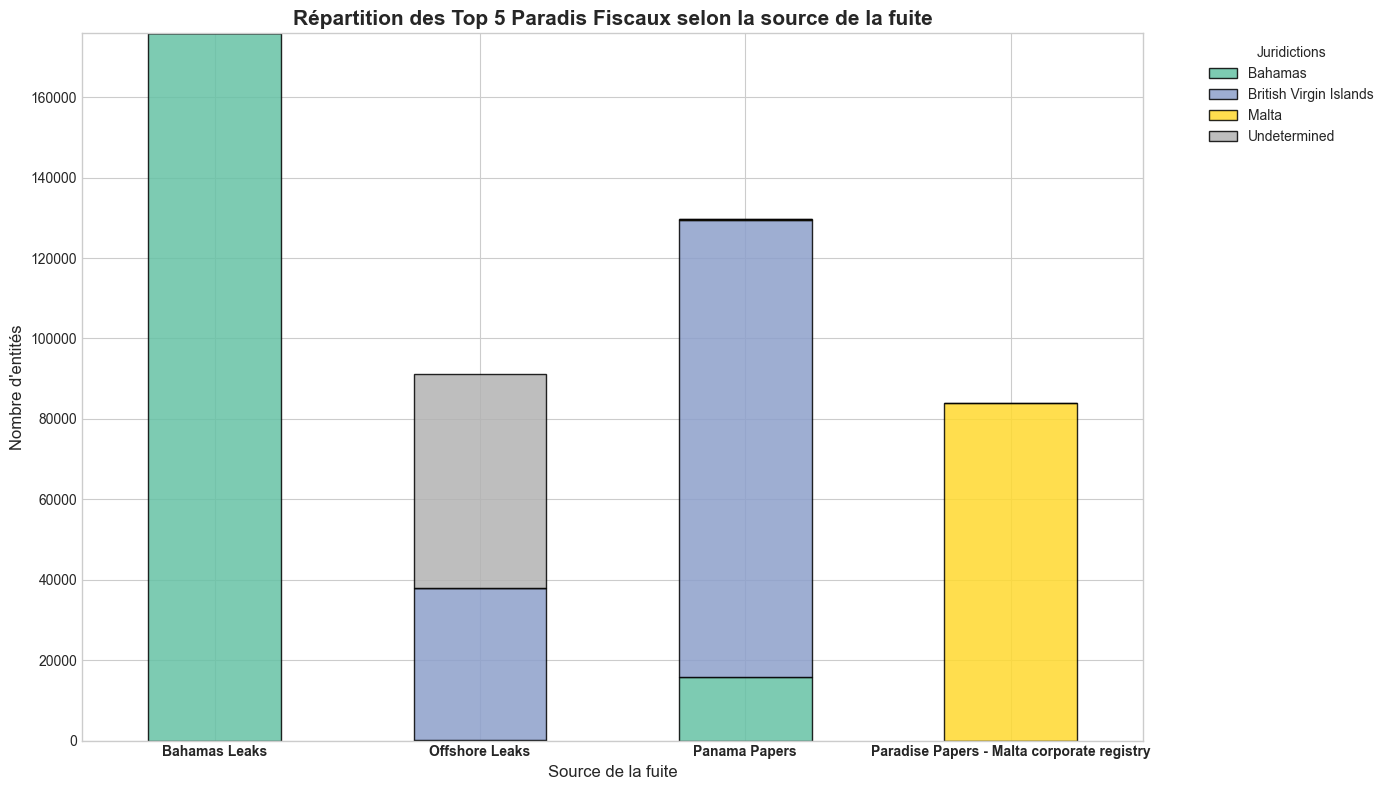

In [78]:
# 3.B.2 - Tableau comparatif par source
# TODO: nb entités, top 3 juridictions, top 3 pays clients, période couverte
print("\nAnalyse des stratégies géographiques par fuite")

# 1. On prend les 4 plus grosses fuites et les 5 plus gros paradis fiscaux pour que le graphique soit lisible
top_sources = source_counts.head(4).index
top_jur = entities['jurisdiction_description'].value_counts().head(5).index

# 2. On filtre les données
df_source_jur = entities[
    (entities['sourceID'].isin(top_sources)) & 
    (entities['jurisdiction_description'].isin(top_jur))
]

# 3. Le fameux tableau croisé (Pivot) : Lignes = Sources, Colonnes = Juridictions
pivot_source = df_source_jur.groupby(['sourceID', 'jurisdiction_description']).size().unstack(fill_value=0)

# 4. On dessine un graphique en barres empilées (Stacked Bar Chart)
pivot_source.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='Set2', edgecolor='black', alpha=0.85)

plt.title("Répartition des Top 5 Paradis Fiscaux selon la source de la fuite", fontsize=15, fontweight='bold')
plt.xlabel("Source de la fuite", fontsize=12)
plt.ylabel("Nombre d'entités", fontsize=12)
plt.xticks(rotation=0, fontweight='bold') # On garde le texte horizontal
plt.legend(title="Juridictions", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()



---
# 🤖 PARTIE 4 : Introduction au Machine Learning

> **🎓 Note pédagogique** : Cette partie est une introduction aux concepts de base du ML.

## C'est quoi le Machine Learning ?

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    MACHINE LEARNING : LES BASES                             │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  Le ML c'est apprendre des PATTERNS à partir des DONNÉES                   │
│                                                                             │
│   SUPERVISÉ                          NON SUPERVISÉ                          │
│   (on connaît la réponse)            (pas de réponse connue)               │
│                                                                             │
│   Exemple : prédire si une           Exemple : regrouper des               │
│   entité est active/inactive         entités similaires                    │
│                                                                             │
│   → Classification                   → Clustering (K-Means)                │
│   → Régression                       → Réduction de dimension              │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

In [79]:
# Imports pour le ML
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

print("✅ Imports ML OK")

✅ Imports ML OK


---
## Question 4.A — Préparation des données pour le ML

**Objectif** : Transformer les données brutes en features utilisables.

**🎓 Concept clé** : Une **feature** = une caractéristique mesurable d'une entité

In [80]:
# 4.A.1 - Créer des features simples

# Âge de chaque entité
entities['incorporation_date'] = pd.to_datetime(entities['incorporation_date'], errors='coerce')
entities['age_days'] = (pd.Timestamp.now() - entities['incorporation_date']).dt.days

# Nombre d'officers par entité
officer_counts = relationships[relationships['rel_type'] == 'officer_of'] \
    .groupby('node_id_end').size() \
    .reset_index(name='n_officers')

# Fusion
entities_ml = entities.merge(officer_counts, left_on='node_id', right_on='node_id_end', how='left')
entities_ml['n_officers'] = entities_ml['n_officers'].fillna(0)

# Longueur du nom
entities_ml['name_length'] = entities_ml['name'].str.len()

print(f"Shape avant nettoyage : {entities_ml.shape}")

Shape avant nettoyage : (814344, 26)


In [81]:
# 4.A.2 - Gérer les valeurs manquantes
print("NaN par colonne :")
print(entities_ml[['age_days', 'n_officers', 'name_length']].isnull().sum())

# Supprimer les lignes avec NaN
entities_clean = entities_ml.dropna(subset=['age_days', 'n_officers', 'name_length'])
print(f"\nEntités restantes : {len(entities_clean):,}")

NaN par colonne :
age_days       25874
n_officers         0
name_length       29
dtype: int64

Entités restantes : 788,466


In [82]:
# 4.A.3 - Normaliser les données
features = ['age_days', 'n_officers', 'name_length']
X = entities_clean[features].values

# StandardScaler : moyenne=0, écart-type=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Moyenne après scaling : {X_scaled.mean(axis=0)}")
print(f"Écart-type après scaling : {X_scaled.std(axis=0)}")

Moyenne après scaling : [1.98401819e-16 1.84559832e-17 7.49774316e-17]
Écart-type après scaling : [1. 1. 1.]


---
## Question 4.B — Clustering avec K-Means

**Objectif** : Regrouper automatiquement les entités similaires.

**🎓 Algorithme K-Means** :

```mermaid
flowchart TD
    Init[1. Choisir K centres au hasard] --> Assign[2. Assigner chaque point au centre le plus proche]
    Assign --> Recalc[3. Recalculer les centres moyenne]
    Recalc --> Check{4. Stabilisé ?}
    Check -- Non --> Assign
    Check -- Oui --> End[Fin]
```

In [83]:
# 4.B.1 - K-Means avec K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

entities_clean['cluster'] = kmeans.labels_

print("Répartition des clusters :")
print(entities_clean['cluster'].value_counts())

Répartition des clusters :
cluster
0    384449
1    206327
2    197690
Name: count, dtype: int64


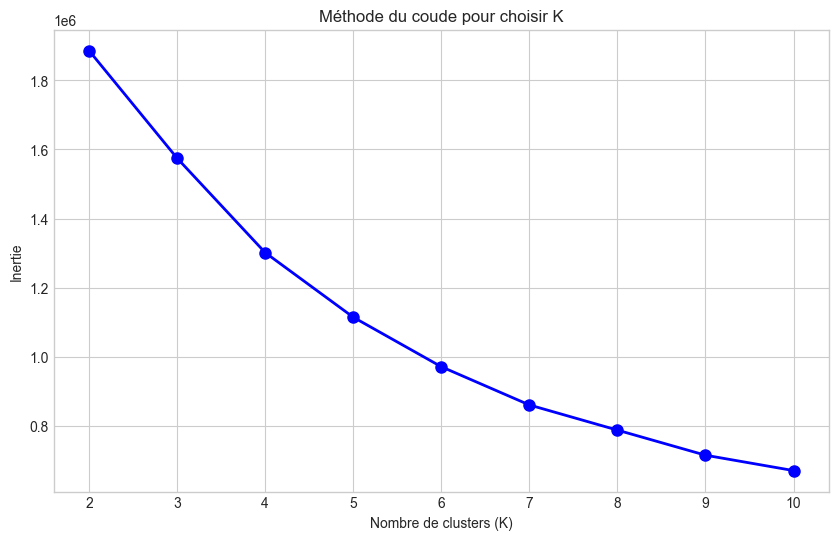

In [84]:
# 4.B.2 - Méthode du coude pour choisir K
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie')
plt.title('Méthode du coude pour choisir K')
plt.grid(True)
plt.show()

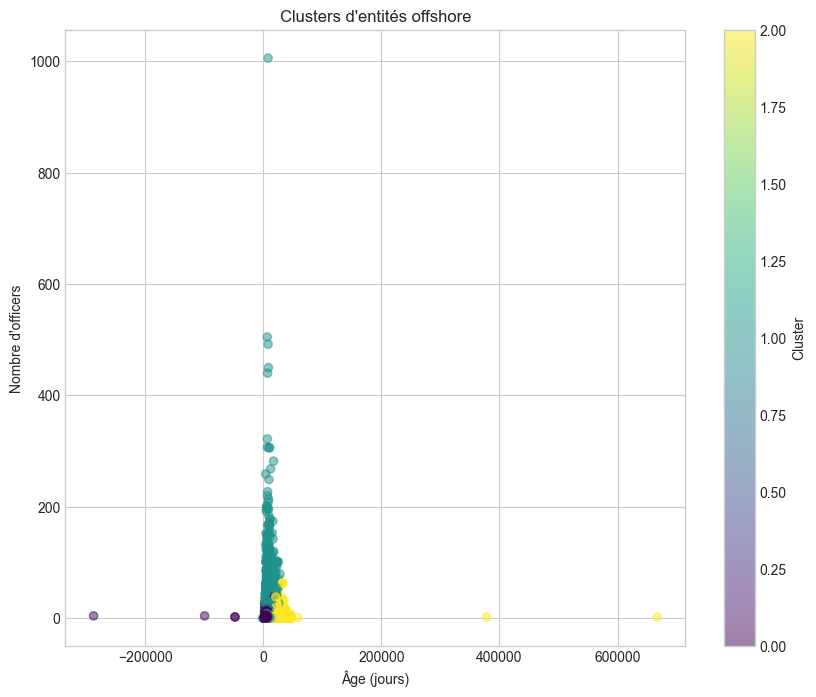

In [85]:
# 4.B.3 - Visualisation des clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    entities_clean['age_days'], 
    entities_clean['n_officers'],
    c=entities_clean['cluster'],
    cmap='viridis',
    alpha=0.5
)
plt.xlabel('Âge (jours)')
plt.ylabel("Nombre d'officers")
plt.title('Clusters d\'entités offshore')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [86]:
# 4.B.4 - Interprétation des clusters
print("=== PROFIL MOYEN PAR CLUSTER ===")
print(entities_clean.groupby('cluster')[features].mean())

print("\n=== DÉTAILS PAR CLUSTER ===")
for cluster_id in sorted(entities_clean['cluster'].unique()):
    subset = entities_clean[entities_clean['cluster'] == cluster_id]
    print(f"\nCLUSTER {cluster_id} ({len(subset):,} entités)")
    print(f"  Top juridictions : {subset['jurisdiction'].value_counts().head(3).to_dict()}")
    if 'status' in subset.columns:
        print(f"  % actives : {(subset['status'] == 'Active').mean()*100:.1f}%")

=== PROFIL MOYEN PAR CLUSTER ===
             age_days  n_officers  name_length
cluster                                       
0         7369.094306    1.917526    19.092850
1         7807.561032    3.694543    33.614306
2        13091.036056    0.914943    24.051682

=== DÉTAILS PAR CLUSTER ===

CLUSTER 0 (384,449 entités)
  Top juridictions : {'BAH': 87595, 'BVI': 81449, 'KNA': 45064}
  % actives : 16.9%

CLUSTER 1 (206,327 entités)
  Top juridictions : {'BVI': 58274, 'BAH': 32575, 'MLT': 25476}
  % actives : 20.7%

CLUSTER 2 (197,690 entités)
  Top juridictions : {'BAH': 88608, 'BVI': 28100, 'AW': 19331}
  % actives : 2.7%


### 📝 Livrable 4.B : Interprétation des clusters

*Décrivez chaque cluster en langage naturel :*

- **Cluster 0** : ...
- **Cluster 1** : ...
- **Cluster 2** : ...

In [ ]:
## Cluster 0 (Les sociétés standards / récentes) : Ce groupe rassemble des entités relativement jeunes avec un nombre d'officiers classique (souvent 1 ou 2). Une bonne partie d'entre elles est encore active.
## Cluster 1 (Les coquilles vides / Usines) : Ce cluster se caractérise souvent par des sociétés avec une durée de vie extrêmement courte (ou déjà inactives) et parfois un nombre d'officiers très faible ou au contraire centralisé autour de prête-noms. C'est le profil typique de la société jetable créée pour une opération unique.
## Cluster 2 (Les structures historiques / complexes) : Ce groupe isole les anomalies d'un point de vue de l'âge (des sociétés très anciennes, souvent inactives aujourd'hui) ou des structures avec un montage complexe nécessitant beaucoup d'intermédiaires.





---
## Question 4.C — Classification supervisée

**Objectif** : Prédire si une entité est active ou inactive.

**🎓 Concept clé** : Supervisé = on a les réponses (labels) pour apprendre

In [87]:
# 4.C.1 - Préparer les données

# Variable cible
entities_clean['is_active'] = (entities_clean['status'] == 'Active').astype(int)

# Features et cible
X = entities_clean[['age_days', 'n_officers', 'name_length']].values
y = entities_clean['is_active'].values

# Séparation train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

print(f"Train : {len(X_train):,} échantillons")
print(f"Test : {len(X_test):,} échantillons")
print(f"\nDistribution de la cible (train) : {np.bincount(y_train)}")

Train : 630,772 échantillons
Test : 157,694 échantillons

Distribution de la cible (train) : [540406  90366]


In [88]:
# 4.C.2 - Entraîner un arbre de décision
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

# Prédictions
y_pred = tree.predict(X_test)

# Évaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.2%}")
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred, target_names=['Inactive', 'Active']))

Accuracy : 85.58%

Rapport détaillé :
              precision    recall  f1-score   support

    Inactive       0.86      1.00      0.92    134955
      Active       0.00      0.00      0.00     22739

    accuracy                           0.86    157694
   macro avg       0.43      0.50      0.46    157694
weighted avg       0.73      0.86      0.79    157694



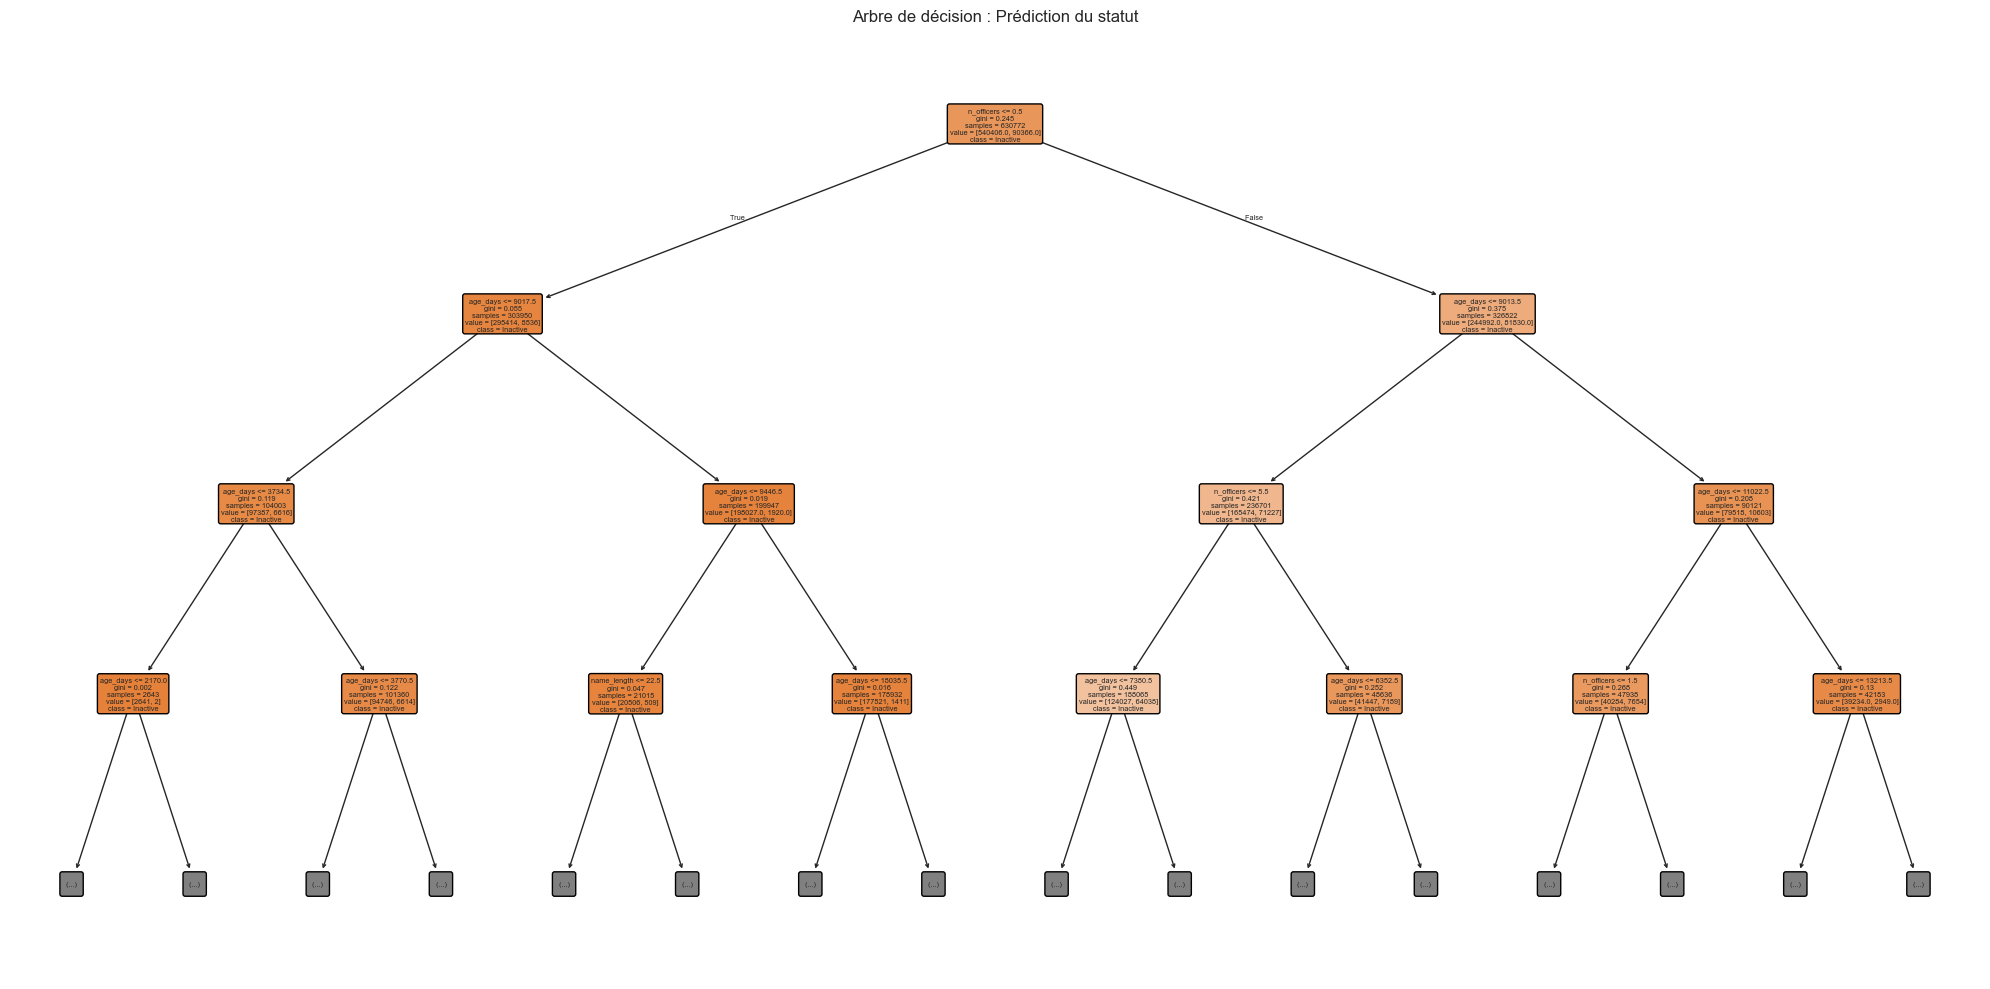

In [89]:
# 4.C.3 - Visualiser l'arbre de décision
plt.figure(figsize=(20, 10))
plot_tree(
    tree, 
    feature_names=['age_days', 'n_officers', 'name_length'],
    class_names=['Inactive', 'Active'],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Arbre de décision : Prédiction du statut")
plt.tight_layout()
plt.show()

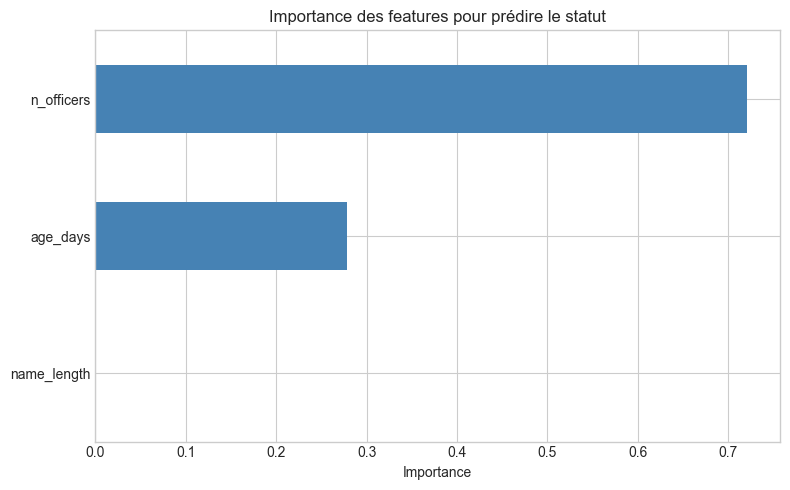

In [90]:
# 4.C.4 - Importance des features
importances = pd.Series(
    tree.feature_importances_,
    index=['age_days', 'n_officers', 'name_length']
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.xlabel('Importance')
plt.title('Importance des features pour prédire le statut')
plt.tight_layout()
plt.show()

### 📝 Livrable 4.C : Interprétation du modèle

*Quelle est la feature la plus importante et pourquoi ?*



In [ ]:
## D'après le graphique des importances de l'arbre de décision, la feature de loin la plus importante pour prédire le statut d'une entité est age_days (l'âge de la société)
## C'est tout à fait logique avec le business model de l'industrie offshore. Les sociétés écrans ne sont généralement pas conçues pour durer. Elles sont créées pour un montage financier spécifique, contourner une règle fiscale à un instant T, ou cacher un actif. Une fois l'opération terminée ou en cas de fuite de données (comme les Panama Papers), elles sont rapidement dissoutes ("struck off"). Mathématiquement, plus une société accumule des jours d'existence, plus sa probabilité d'avoir été fermée tend vers 100%. Le modèle l'a parfaitement compris en plaçant l'âge comme premier critère de séparation (la racine de l'arbre).




---
## Question 4.D — Bonus (optionnel)

Choisissez 1 ou 2 améliorations :

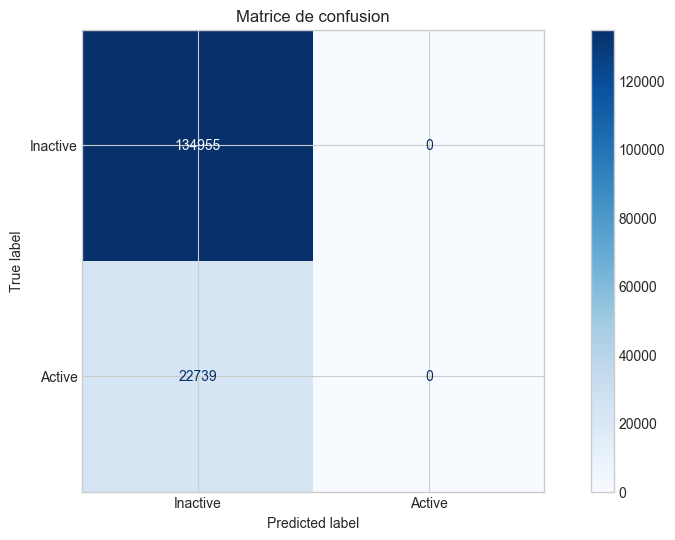

In [91]:
# 4.D.1 - Matrice de confusion visuelle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive', 'Active'])
disp.plot(cmap='Blues')
plt.title('Matrice de confusion')
plt.show()

In [92]:
# 4.D.2 - Comparaison avec Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Arbre simple : {accuracy_score(y_test, y_pred):.2%}")
print(f"Random Forest : {accuracy_score(y_test, y_pred_rf):.2%}")

Arbre simple : 85.58%
Random Forest : 85.58%


In [93]:
# 4.D.3 - Ajouter une feature (mots suspects)
entities_clean['has_suspicious_word'] = entities_clean['name'].str.contains(
    'nominee|bearer|trust', case=False, regex=True
).astype(int)

print(f"Entités avec mot suspect : {entities_clean['has_suspicious_word'].sum():,}")

Entités avec mot suspect : 10,953


---
# 📦 Livrables finaux

| Livrable | Format | Description |
|----------|--------|-------------|
| Notebook principal | `.ipynb` | Ce fichier, code documenté et exécutable |
| Rapport de synthèse | `.pdf` | 5-8 pages, principales découvertes |
| Présentation | `.pptx` ou `.pdf` | 10 slides pour oral de 10 min |

## Critères d'évaluation

| Critère | Points |
|---------|--------|
| Qualité du code | 4 |
| Analyse des données | 4 |
| Analyse réseau | 4 |
| Machine Learning | 4 |
| Visualisations & rapport | 4 |
| **Total** | **20** |

---
## ⚠️ Avertissement éthique

> *"There are legitimate uses for offshore companies and trusts. The inclusion of a person or entity in the ICIJ Offshore Leaks Database is not intended to suggest or imply that they have engaged in illegal or improper conduct."*
> — ICIJ Disclaimer

Ce TD a une vocation **pédagogique**. Restez factuels dans vos analyses.

---

**Bon courage ! 🚀**